# DOSSIER — ablation studies on NF-ToN-IoT-v2

Reproduces paper Table 10 (NF-ToN-IoT-v2 column) and the NF-ToN-IoT-v2 row of Table 17.

The notebook re-runs the shared pipeline (graph construction, inference, faithfulness, LLM stage) and then
appends the ablation sections at the end. The seed-42 model is **loaded** from
`../outputs/nf_ton_iot_v2/rag_ids_v4_seed42.pt` when present, otherwise trained from scratch.

**Which outputs below are reported in the paper**
- The ablation section (paper Table 10) and the faithfulness section (paper Table 17).
- The **LLM-stage** outputs are a second, independent execution of the explanation stage; the paper's
  Tables 13–15 come from the main notebook. Paper Sec. 11.2 (item 2) reports this run-to-run variation.
- The **multi-seed** cell reloaded a cached `multi_seed_results.csv`; the reported Table 11 values are in
  the main notebook.
**Table numbering.** Printed labels in the saved outputs follow an earlier draft of the manuscript:
printed "Table 8" = paper **Table 9**, printed "Table 9" = paper **Table 10**, printed "Table 16" = paper **Table 17**.

**Naming note.** Audit checks `H1`–`H5` in code correspond to paper S1, S2, H1, H2, H3.

In [3]:
import os, json, re, random, copy, time, warnings
from collections import defaultdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

import torch_geometric
from torch_geometric.data import Data
from torch_geometric.nn import MessagePassing

import faiss
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import networkx as nx

warnings.filterwarnings('ignore')

In [4]:
# =============================================================================
# 1. REPRODUCIBILITY & CONFIG
# =============================================================================

def set_seed(s: int):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True

SEEDS      = [42, 123, 7, 2024, 999]
SEED       = SEEDS[0]
set_seed(SEED)

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
INDUCTIVE  = True   # message passing on training edges only (paper setting)
MULTI_SEED = True   # run the five-seed robustness evaluation

OUTPUT_DIR = Path(os.environ.get("DOSSIER_OUTPUT_DIR", "../outputs/nf_ton_iot_v2"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"PyTorch {torch.__version__}  |  Device: {DEVICE}")
print(f"Output → {OUTPUT_DIR.resolve()}")


# Artifacts reused from OUTPUT_DIR when present:
#   rag_ids_v4_seed{SEED}.pt   seed-42 checkpoint (loaded instead of retraining)
#   multi_seed_results.csv     five-seed results (loaded instead of re-running)

PyTorch 2.5.1+cu121  |  Device: cuda
Output → <output_dir>


In [5]:
# =============================================================================
# 2. TIMING UTILITIES
# =============================================================================

GLOBAL_START = time.time()
STAGE_TIMES  = {}

def start_stage(name: str) -> float:
    print(f"\n{'='*80}\n[START] {name}\n{'='*80}")
    return time.time()

def end_stage(name: str, t0: float):
    elapsed = time.time() - t0
    STAGE_TIMES[name] = elapsed
    h, m, s = int(elapsed//3600), int((elapsed%3600)//60), elapsed%60
    print(f"[END] {name}  |  {h:02d}:{m:02d}:{s:05.2f}\n{'='*80}\n")

def print_timing_summary():
    total = time.time() - GLOBAL_START
    print("\n" + "="*80 + "\nTIMING SUMMARY\n" + "="*80)
    for name, elapsed in STAGE_TIMES.items():
        h, m, s = int(elapsed//3600), int((elapsed%3600)//60), elapsed%60
        print(f"  {name:<45} {h:02d}:{m:02d}:{s:05.2f}")
    h, m, s = int(total//3600), int((total%3600)//60), total%60
    print(f"  {'TOTAL':<45} {h:02d}:{m:02d}:{s:05.2f}\n" + "="*80)

In [6]:
# =============================================================================
# 3. DATASET LOADING
# =============================================================================

DATA_DIR  = Path(os.environ.get("DOSSIER_DATA_DIR", "../data"))
DATA_PATH = DATA_DIR / "NF-ToN-IoT-v2_targetCounts.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

t = start_stage("Dataset Loading")
df = pd.read_csv(DATA_PATH)
end_stage("Dataset Loading", t)

print(f"Shape: {df.shape}")
print(df['Attack'].value_counts().to_string())


[START] Dataset Loading
[END] Dataset Loading  |  00:00:09.16

Shape: (1433569, 45)
Attack
Benign        700000
scanning      210000
xss           140000
ddos          140000
password       84000
dos            70000
injection      70000
backdoor       11766
mitm            5406
ransomware      2397


In [7]:
# =============================================================================
# 4. GRAPH CONSTRUCTION
# =============================================================================

t = start_stage("Graph Construction")

ID_COLS    = ['IPV4_SRC_ADDR', 'IPV4_DST_ADDR']
LABEL_COLS = ['Label', 'Attack']

# Columns derived later in this cell; excluded so the feature list is stable on re-runs.
DERIVED_COLS = ['src_idx', 'dst_idx', 'attack_id']

# Absolute-timestamp columns are kept as edge features (their effect is quantified
# in paper Sec. 5.4). This list is used only by the temporal-attribution audit.
TEMPORAL_COLS = [
    'FLOW_START_MILLISECONDS',
    'FLOW_END_MILLISECONDS',
]

# All non-identifier, non-label columns are edge features.
EDGE_FEATURE_COLS = [
    c for c in df.columns
    if c not in ID_COLS + LABEL_COLS + DERIVED_COLS
]

# Column indices used by the temporal-attribution audit.
TEMPORAL_COL_IDX = {
    EDGE_FEATURE_COLS.index(c)
    for c in TEMPORAL_COLS
    if c in EDGE_FEATURE_COLS
}

print(f"edge_feat_dim will be: {len(EDGE_FEATURE_COLS)}")
print("Temporal features included (by design):")
for c in TEMPORAL_COLS:
    if c in EDGE_FEATURE_COLS:
        print(f"  ✓ {c}")


def check_temporal_importance(attr: np.ndarray, top_n: int = 5):
    """Return (and log) the temporal columns among the top-N attributed features."""
    top_idx   = set(np.argsort(attr)[-top_n:].tolist())
    important = top_idx & TEMPORAL_COL_IDX
    if important:
        names = [EDGE_FEATURE_COLS[i] for i in important]
        print(f"  [audit] Temporal features in top-{top_n} attribution: {names}")
    return important


# ── Numeric conversion and NaN cleaning ──────────────────────────────────────
df[EDGE_FEATURE_COLS] = df[EDGE_FEATURE_COLS].apply(pd.to_numeric, errors='coerce')
edge_feats_raw = df[EDGE_FEATURE_COLS].values.astype(np.float32)
edge_feats_raw = np.nan_to_num(edge_feats_raw, nan=0.0, posinf=0.0, neginf=0.0)

# Verify column count is correct before continuing
assert edge_feats_raw.shape[1] == 41, (
    f"Expected 41 edge features, got {edge_feats_raw.shape[1]}. "
    f"Columns in df: {[c for c in df.columns if c not in ID_COLS + LABEL_COLS]}"
)
print(f"✓ edge_feats_raw shape: {edge_feats_raw.shape}  (41 features confirmed)")

# =============================================================================
# 4b. NUMERIC-FAITHFULNESS EXCLUSION SET
# =============================================================================
# Epoch-scale columns skipped by the numeric-faithfulness check
# (implemented as H4 below; H2 in the paper).
NUMERIC_CHECK_EXCLUDE = {
    'FLOW_START_MILLISECONDS',
    'FLOW_END_MILLISECONDS',
}
# Also skip any column whose mean value exceeds 1e9 (epoch-scale counters).
_n_feat_cols = edge_feats_raw.shape[1]
for _col in EDGE_FEATURE_COLS[:_n_feat_cols]:
    _col_idx  = EDGE_FEATURE_COLS.index(_col)
    if _col_idx >= _n_feat_cols:
        continue
    _col_mean = float(np.nanmean(edge_feats_raw[:, _col_idx]))
    if _col_mean > 1e9:
        NUMERIC_CHECK_EXCLUDE.add(_col)

print(f"H4 numeric check — skipping {len(NUMERIC_CHECK_EXCLUDE)} large-scale columns:")
for _c in sorted(NUMERIC_CHECK_EXCLUDE):
    print(f"  ✗ {_c}")

# ── Label encoding ────────────────────────────────────────────────────────────
le = LabelEncoder()
df['attack_id'] = le.fit_transform(df['Attack']).astype(np.int64)
N_CLASSES    = len(le.classes_)
benign_class = int(le.transform(['Benign'])[0])
print(f"Classes: {dict(zip(le.classes_, range(N_CLASSES)))}")
print(f"Benign class id: {benign_class}")

# ── Three-way stratified split ────────────────────────────────────────────────
indices = np.arange(len(df))
trainval_idx, test_idx = train_test_split(
    indices, test_size=0.20, stratify=df['attack_id'], random_state=SEED)
train_idx, val_idx = train_test_split(
    trainval_idx, test_size=0.125,
    stratify=df['attack_id'].values[trainval_idx], random_state=SEED)
print(f"train={len(train_idx)}  val={len(val_idx)}  test={len(test_idx)}")

# ── Scaler: fit on TRAIN ONLY ─────────────────────────────────────────────────
scaler = StandardScaler().fit(edge_feats_raw[train_idx])
edge_feats_scaled = scaler.transform(edge_feats_raw).astype(np.float32)

# ── Class weights: from TRAIN ONLY ───────────────────────────────────────────
train_counts = np.bincount(df['attack_id'].values[train_idx], minlength=N_CLASSES)
train_counts = np.clip(train_counts, 1, None)
beta   = 0.9999
eff    = 1.0 - np.power(beta, train_counts)
raw_w  = (1.0 - beta) / eff
class_weights = torch.tensor(
    raw_w / raw_w.sum() * N_CLASSES, dtype=torch.float32, device=DEVICE)
print(f"Class weights: {class_weights.cpu().numpy().round(3)}")

# ── Graph tensors ─────────────────────────────────────────────────────────────
all_ips   = pd.concat([df['IPV4_SRC_ADDR'], df['IPV4_DST_ADDR']]).unique()
ip_to_idx = {ip: i for i, ip in enumerate(all_ips)}
df['src_idx'] = df['IPV4_SRC_ADDR'].map(ip_to_idx)
df['dst_idx'] = df['IPV4_DST_ADDR'].map(ip_to_idx)
n_nodes = len(ip_to_idx)

src         = torch.tensor(df['src_idx'].values, dtype=torch.long)
dst         = torch.tensor(df['dst_idx'].values, dtype=torch.long)
edge_index  = torch.stack([src, dst], dim=0)
edge_attr   = torch.tensor(edge_feats_scaled, dtype=torch.float32)
edge_attr_r = torch.tensor(edge_feats_raw,    dtype=torch.float32)
edge_y      = torch.tensor(df['attack_id'].values, dtype=torch.long)
edge_y_bin  = torch.tensor(df['Label'].values,     dtype=torch.long)

# ── Node features: built from TRAIN edges only ───────────────────────────────
# Per-node mean and standard deviation of selected edge attributes.
STAT_COLS     = ['IN_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'MIN_TTL']
stat_cols_idx = [EDGE_FEATURE_COLS.index(c) for c in STAT_COLS if c in EDGE_FEATURE_COLS]

out_deg = np.zeros(n_nodes, np.float64)
in_deg  = np.zeros(n_nodes, np.float64)
np.add.at(out_deg, df['src_idx'].values[train_idx], 1)
np.add.at(in_deg,  df['dst_idx'].values[train_idx], 1)
tot_deg = in_deg + out_deg
ratio   = np.log1p(in_deg) - np.log1p(out_deg)

struct = [np.log1p(in_deg), np.log1p(out_deg), np.log1p(tot_deg), ratio]

for ci in stat_cols_idx:
    col_vals = edge_feats_raw[:, ci]
    src_tr   = df['src_idx'].values[train_idx]
    dst_tr   = df['dst_idx'].values[train_idx]
    vals_tr  = col_vals[train_idx]

    # mean pass
    mean_arr = np.zeros(n_nodes)
    np.add.at(mean_arr, src_tr, vals_tr)
    np.add.at(mean_arr, dst_tr, vals_tr)
    mean_arr /= (tot_deg + 1e-9)
    struct.append(np.log1p(np.abs(mean_arr)))

    # std pass
    std_arr = np.zeros(n_nodes)
    np.add.at(std_arr, src_tr, (vals_tr - mean_arr[src_tr]) ** 2)
    np.add.at(std_arr, dst_tr, (vals_tr - mean_arr[dst_tr]) ** 2)
    std_arr = np.sqrt(std_arr / (tot_deg + 1e-9))
    struct.append(np.log1p(np.abs(std_arr)))

node_struct = np.stack(struct, axis=1).astype(np.float32)
node_struct = (node_struct - node_struct.mean(0)) / (node_struct.std(0) + 1e-9)
x = torch.tensor(node_struct, dtype=torch.float32)
node_feat_dim = x.size(1)
print(f"node_feat_dim: {node_feat_dim}  |  edge_feat_dim: {edge_attr.size(1)}")

# ── PyG Data object ───────────────────────────────────────────────────────────
graph = Data(
    x=x, edge_index=edge_index,
    edge_attr=edge_attr, edge_attr_raw=edge_attr_r,
    edge_y=edge_y, edge_y_binary=edge_y_bin,
)
for name, idx_arr in [('train', train_idx), ('val', val_idx), ('test', test_idx)]:
    mask = torch.zeros(len(df), dtype=torch.bool)
    mask[idx_arr] = True
    setattr(graph, f'{name}_edge_mask', mask)

end_stage("Graph Construction", t)


[START] Graph Construction
edge_feat_dim will be: 41
Temporal features included (by design):
✓ edge_feats_raw shape: (1433569, 41)  (41 features confirmed)
H4 numeric check — skipping 4 large-scale columns:
  ✗ DST_TO_SRC_SECOND_BYTES
  ✗ FLOW_END_MILLISECONDS
  ✗ FLOW_START_MILLISECONDS
  ✗ SRC_TO_DST_SECOND_BYTES
Classes: {'Benign': 0, 'backdoor': 1, 'ddos': 2, 'dos': 3, 'injection': 4, 'mitm': 5, 'password': 6, 'ransomware': 7, 'scanning': 8, 'xss': 9}
Benign class id: 0
train=1003498  val=143357  test=286714
Class weights: [0.542 0.966 0.542 0.546 0.546 1.721 0.544 3.509 0.542 0.542]
node_feat_dim: 12  |  edge_feat_dim: 41
[END] Graph Construction  |  00:00:12.40



In [8]:
# =============================================================================
# 5. MODEL ARCHITECTURE
# =============================================================================

class EdgeSAGEConv(MessagePassing):
    def __init__(self, in_ch: int, edge_ch: int, out_ch: int):
        super().__init__(aggr='mean')
        self.lin_msg  = nn.Linear(in_ch + edge_ch, out_ch)
        self.lin_self = nn.Linear(in_ch, out_ch)
        self.norm     = nn.LayerNorm(out_ch)

    def forward(self, x, edge_index, edge_attr):
        out = self.propagate(edge_index, x=x, edge_attr=edge_attr)
        return F.relu(self.norm(out + self.lin_self(x)))

    def message(self, x_j, edge_attr):
        return F.relu(self.lin_msg(torch.cat([x_j, edge_attr], dim=-1)))


class EGraphSAGEv4(nn.Module):
    """
    DOSSIER detector: inductive, edge-centric GNN (E-GraphSAGE family).

      - 3 edge-conditioned message-passing layers + jumping-knowledge fusion
      - interaction-aware edge descriptor z_uv = [h_u, h_v, h_u-h_v, h_u*h_v, e_uv]
      - reconstruction branch whose standardised error enters the classifier
        through a learned gate
      - retrieval projection: 128-d L2-normalised key used for FAISS search.
        It is not on the computation path of any loss term, so its parameters
        remain at initialisation (paper Sec. 3.3).
    """
    def __init__(self, node_in: int, edge_in: int,
                 hidden: int = 192, edge_hidden: int = 96,
                 n_classes: int = 10):
        super().__init__()
        # running statistics of the reconstruction error (EMA-updated during training)
        self.register_buffer("rec_mean", torch.tensor(0.0))
        self.register_buffer("rec_std",  torch.tensor(1.0))

        # edge encoder
        self.edge_enc = nn.Sequential(
            nn.Linear(edge_in, edge_hidden), nn.ReLU(), nn.LayerNorm(edge_hidden))

        # GNN stack
        self.conv1 = EdgeSAGEConv(node_in,  edge_hidden, hidden)
        self.conv2 = EdgeSAGEConv(hidden,   edge_hidden, hidden)
        self.conv3 = EdgeSAGEConv(hidden,   edge_hidden, hidden)
        self.drop  = nn.Dropout(0.3)
        self.jk    = nn.Sequential(
            nn.Linear(3 * hidden, hidden), nn.ReLU(), nn.LayerNorm(hidden))

        edge_feat_dim = 4 * hidden + edge_hidden

        # gated reconstruction fusion
        self.rec_gate = nn.Sequential(
            nn.Linear(edge_feat_dim, 1), nn.Sigmoid())

        # classifier
        self.edge_clf = nn.Sequential(
            nn.Linear(edge_feat_dim + 1, hidden), nn.ReLU(),
            nn.LayerNorm(hidden), nn.Dropout(0.3),
            nn.Linear(hidden, n_classes))

        # reconstruction head (trained on benign only)
        self.edge_recon = nn.Sequential(
            nn.Linear(2 * hidden + edge_hidden, hidden), nn.ReLU(),
            nn.LayerNorm(hidden), nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, edge_in))

        # retrieval projection (128-d key for FAISS search)
        self.retrieval_proj = nn.Sequential(
            nn.Linear(edge_feat_dim, hidden), nn.ReLU(),
            nn.LayerNorm(hidden), nn.Linear(hidden, 128))

    def encode(self, x, mp_ei, mp_enc):
        h1 = self.drop(self.conv1(x,  mp_ei, mp_enc))
        h2 = self.drop(self.conv2(h1, mp_ei, mp_enc))
        h3 =           self.conv3(h2, mp_ei, mp_enc)
        return self.jk(torch.cat([h1, h2, h3], dim=-1))

    def forward(self, x, mp_ei, mp_ea,
                target_ei=None, target_ea=None):
        if target_ei is None: target_ei = mp_ei
        if target_ea is None: target_ea = mp_ea

        mp_enc   = self.edge_enc(mp_ea)
        h        = self.encode(x, mp_ei, mp_enc)

        t_enc    = self.edge_enc(target_ea)
        u, v     = target_ei
        h_u, h_v = h[u], h[v]

        # reconstruction anomaly signal
        recon   = self.edge_recon(torch.cat([h_u, h_v, t_enc], dim=-1))
        rec_err = ((recon - target_ea).pow(2)).mean(dim=-1, keepdim=True)
        rec_z   = (rec_err - self.rec_mean) / (self.rec_std + 1e-6)
        rec_z   = torch.nan_to_num(rec_z, nan=0., posinf=5., neginf=-5.)
        rec_z   = torch.clamp(rec_z, -5., 5.)

        edge_feat = torch.cat([h_u, h_v, h_u - h_v, h_u * h_v, t_enc], dim=-1)

        # gated fusion of reconstruction signal
        gate    = self.rec_gate(edge_feat)
        gated_r = gate * torch.sigmoid(rec_z)

        logits = self.edge_clf(torch.cat([edge_feat, gated_r], dim=-1))
        r_emb  = F.normalize(self.retrieval_proj(edge_feat), p=2, dim=-1)

        return logits, recon, h, r_emb


# ── Ablation subclasses ───────────────────────────────────────────────────────

class EGraphSAGEv4_NoRecon(EGraphSAGEv4):
    """Ablation "w/o gated reconstruction": the gated reconstruction input to the classifier is zeroed."""
    def forward(self, x, mp_ei, mp_ea, target_ei=None, target_ea=None):
        if target_ei is None: target_ei = mp_ei
        if target_ea is None: target_ea = mp_ea
        mp_enc    = self.edge_enc(mp_ea)
        h         = self.encode(x, mp_ei, mp_enc)
        t_enc     = self.edge_enc(target_ea)
        u, v      = target_ei
        h_u, h_v  = h[u], h[v]
        recon     = self.edge_recon(torch.cat([h_u, h_v, t_enc], dim=-1))
        edge_feat = torch.cat([h_u, h_v, h_u - h_v, h_u * h_v, t_enc], dim=-1)
        rec_zero  = torch.zeros(h_u.size(0), 1, device=h_u.device)
        logits    = self.edge_clf(torch.cat([edge_feat, rec_zero], dim=-1))
        r_emb     = F.normalize(self.retrieval_proj(edge_feat), p=2, dim=-1)
        return logits, recon, h, r_emb


class EGraphSAGEv4_NoGate(EGraphSAGEv4):
    """Fixed-gate variant (gate = 0.5). Defined for completeness; not used in the reported results."""
    def forward(self, x, mp_ei, mp_ea, target_ei=None, target_ea=None):
        if target_ei is None: target_ei = mp_ei
        if target_ea is None: target_ea = mp_ea
        mp_enc    = self.edge_enc(mp_ea)
        h         = self.encode(x, mp_ei, mp_enc)
        t_enc     = self.edge_enc(target_ea)
        u, v      = target_ei
        h_u, h_v  = h[u], h[v]
        recon     = self.edge_recon(torch.cat([h_u, h_v, t_enc], dim=-1))
        rec_err   = ((recon - target_ea).pow(2)).mean(dim=-1, keepdim=True)
        rec_z     = (rec_err - self.rec_mean) / (self.rec_std + 1e-6)
        rec_z     = torch.clamp(torch.nan_to_num(rec_z, 0., 5., -5.), -5., 5.)
        edge_feat = torch.cat([h_u, h_v, h_u - h_v, h_u * h_v, t_enc], dim=-1)
        fixed     = torch.full((h_u.size(0), 1), 0.5, device=h_u.device)
        gated_r   = fixed * torch.sigmoid(rec_z)
        logits    = self.edge_clf(torch.cat([edge_feat, gated_r], dim=-1))
        r_emb     = F.normalize(self.retrieval_proj(edge_feat), p=2, dim=-1)
        return logits, recon, h, r_emb

In [9]:
# =============================================================================
# 6. LOSS FUNCTIONS
# =============================================================================

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, target):
        logp = F.log_softmax(logits, dim=-1)
        ce   = F.nll_loss(logp, target, weight=self.alpha, reduction='none')
        pt   = logp.gather(1, target.unsqueeze(1)).squeeze(1).exp()
        return ((1 - pt) ** self.gamma * ce).mean()


# Focal loss with effective-number class weights (paper Eq. 7).

criterion_cls = FocalLoss(alpha=class_weights, gamma=2.0)

In [10]:
# =============================================================================
# 7. TRAINING
# =============================================================================

def build_model_and_optim(seed: int, device, model_class=None,
                           node_in: int = None, edge_in: int = None):
    set_seed(seed)
    ni  = node_in  if node_in  is not None else node_feat_dim
    ei  = edge_in  if edge_in  is not None else graph.edge_attr.size(1)
    cls = model_class if model_class is not None else EGraphSAGEv4
    m   = cls(node_in=ni, edge_in=ei, hidden=192,
               edge_hidden=96, n_classes=N_CLASSES).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=5e-4, weight_decay=1e-5)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='max', factor=0.5, patience=8)
    return m, opt, sch


def train_one_seed(seed: int, g: Data,
                   EPOCHS: int = 200, PATIENCE: int = 25,
                   BATCH: int = 16384,
                   verbose: bool = True,
                   model_class=None,
                   node_in: int = None,
                   label: str = "") -> tuple:
    """
    Train one model (main model, ablation variants and multi-seed runs).

    Loss = Focal(cls) + lambda_rec(t) * log1p(MSE_recon on benign edges),
    with lambda_rec ramped linearly from 0 to 0.05 over the first 20 epochs.
    Model selection and early stopping use validation macro-F1.

    Returns (model, history_dict).
    """
    g = g.to(DEVICE)

    model, optimizer, scheduler = build_model_and_optim(
        seed, DEVICE, model_class=model_class,
        node_in=node_in, edge_in=g.edge_attr.size(1))

    full_ei = g.edge_index
    full_ea = g.edge_attr

    train_ids = g.train_edge_mask.nonzero(as_tuple=True)[0]
    val_ids   = g.val_edge_mask.nonzero(as_tuple=True)[0]

    # ── inductive message-passing graph ──────────────────────────────────────
    if INDUCTIVE:
        mp_ei = full_ei[:, g.train_edge_mask]
        mp_ea = full_ea[g.train_edge_mask]
    else:
        mp_ei, mp_ea = full_ei, full_ea   # transductive (not used for reported results)

    best_val_f1, best_state, bad = -1.0, None, 0

    hist = {k: [] for k in
            ['tr_loss', 'va_loss', 'tr_f1', 'va_f1', 'tr_cls', 'tr_rec']}

    # reset reconstruction-error statistics
    with torch.no_grad():
        model.rec_mean.fill_(0.0)
        model.rec_std.fill_(1.0)

    prefix = f"[{label}] " if label else ""

    for epoch in range(EPOCHS):
        model.train()

        # ── per-epoch reconstruction statistics update ────────────────────
        # EMA (momentum 0.9) over 8,192 randomly sampled training edges
        with torch.no_grad():
            samp  = train_ids[torch.randperm(len(train_ids), device=DEVICE)
                              [:min(8192, len(train_ids))]]
            s_ei  = full_ei[:, samp]
            s_ea  = full_ea[samp]
            _, recon_s, _, _ = model(g.x, mp_ei, mp_ea,
                                     target_ei=s_ei, target_ea=s_ea)
            err_s = (recon_s - s_ea).pow(2).mean(dim=-1, keepdim=True)

            new_mean = torch.nan_to_num(
                err_s.mean().detach(), nan=0.0, posinf=1.0, neginf=0.0)
            new_std  = torch.nan_to_num(
                err_s.std().detach() if err_s.numel() > 1
                else torch.tensor(1e-6, device=DEVICE),
                nan=1e-6, posinf=1.0, neginf=1e-6).clamp(min=1e-6)

            model.rec_mean.copy_(0.9 * model.rec_mean + 0.1 * new_mean)
            model.rec_std.copy_( 0.9 * model.rec_std  + 0.1 * new_std)

        # ── mini-batch training ───────────────────────────────────────────
        perm      = torch.randperm(len(train_ids), device=DEVICE)
        train_ids = train_ids[perm]

        ep_loss = ep_cls = ep_rec = 0.0
        preds_all, labels_all = [], []
        lambda_rec = min(epoch / 20.0, 1.0) * 0.05

        for start in range(0, len(train_ids), BATCH):
            optimizer.zero_grad(set_to_none=True)

            bids   = train_ids[start:start + BATCH]
            b_ei   = full_ei[:, bids]
            b_ea   = full_ea[bids]
            labels = g.edge_y[bids]

            logits, recon, _, _ = model(
                g.x, mp_ei, mp_ea, target_ei=b_ei, target_ea=b_ea)

            # classification loss
            cls_loss = torch.clamp(criterion_cls(logits, labels), 0., 5.)

            # reconstruction loss on benign flows only
            bmask = (labels == benign_class)
            rec_loss = (torch.log1p(F.mse_loss(recon[bmask], b_ea[bmask]))
                        if bmask.sum() > 0
                        else torch.tensor(0., device=DEVICE))

            # total loss: classification + weighted reconstruction
            loss = cls_loss + lambda_rec * rec_loss
            loss = torch.nan_to_num(loss, nan=1., posinf=5., neginf=0.)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            ep_loss += loss.item()
            ep_cls  += cls_loss.item()
            ep_rec  += rec_loss.item()
            preds_all.append(logits.argmax(-1).detach().cpu())
            labels_all.append(labels.detach().cpu())

        # ── validation ───────────────────────────────────────────────────
        model.eval()
        vp, vt, va_loss = [], [], 0.0
        with torch.no_grad():
            for start in range(0, len(val_ids), BATCH):
                bids     = val_ids[start:start + BATCH]
                logits_v, _, _, _ = model(
                    g.x, mp_ei, mp_ea,
                    target_ei=full_ei[:, bids], target_ea=full_ea[bids])
                labs = g.edge_y[bids]
                va_loss += criterion_cls(logits_v, labs).item()
                vp.append(logits_v.argmax(-1).cpu())
                vt.append(labs.cpu())

        vp    = torch.cat(vp).numpy()
        vt    = torch.cat(vt).numpy()
        va_f1 = f1_score(vt, vp, average='macro', zero_division=0)
        tr_f1 = f1_score(
            torch.cat(labels_all).numpy(),
            torch.cat(preds_all).numpy(),
            average='macro', zero_division=0)

        n_tr = max(1, int(np.ceil(len(train_ids) / BATCH)))
        n_va = max(1, int(np.ceil(len(val_ids)   / BATCH)))

        hist['tr_loss'].append(ep_loss / n_tr)
        hist['va_loss'].append(va_loss / n_va)
        hist['tr_f1'].append(tr_f1)
        hist['va_f1'].append(va_f1)
        hist['tr_cls'].append(ep_cls / n_tr)
        hist['tr_rec'].append(ep_rec / n_tr)

        # ── checkpoint & early stopping ───────────────────────────────────
        if va_f1 > best_val_f1:
            best_val_f1 = va_f1
            # snapshot weights and reconstruction statistics
            best_state = {
                'weights':  copy.deepcopy(model.state_dict()),
                'rec_mean': model.rec_mean.clone(),
                'rec_std':  model.rec_std.clone(),
            }
            bad = 0
        else:
            bad += 1

        scheduler.step(va_f1)

        if verbose and (epoch + 1) % 10 == 0:
            print(f"  {prefix}Ep {epoch+1:03d} | "
                  f"tr_loss {ep_loss/n_tr:.4f} | va_loss {va_loss/n_va:.4f} | "
                  f"tr_F1 {tr_f1:.4f} | va_F1 {va_f1:.4f} | best {best_val_f1:.4f}")

        if bad >= PATIENCE:
            if verbose:
                print(f"  {prefix}Early stopping at epoch {epoch+1}  "
                      f"best val-F1={best_val_f1:.4f}")
            break

    # restore the best checkpoint (weights and reconstruction statistics)
    model.load_state_dict(best_state['weights'])
    model.rec_mean.copy_(best_state['rec_mean'])
    model.rec_std.copy_( best_state['rec_std'])

    return model, hist

In [11]:
# =============================================================================
# 8. MAIN MODEL TRAINING
# =============================================================================
# Loads OUTPUT_DIR/rag_ids_v4_seed{SEED}.pt if it exists (weights, reconstruction
# statistics and scaler are restored); otherwise trains and saves it.
# =============================================================================

CKPT = OUTPUT_DIR / f"rag_ids_v4_seed{SEED}.pt"

if CKPT.exists():
    print(f"Found existing checkpoint -> {CKPT.resolve()}")
    ckpt = torch.load(CKPT, map_location=DEVICE, weights_only=False)

    assert ckpt['edge_feat_dim'] == graph.edge_attr.size(1), (
        "Checkpoint edge-feature dim doesn't match this session's graph -- "
        "did the dataset/graph construction change since this checkpoint was "
        "saved? If so, delete the stale .pt file and retrain."
    )

    model = EGraphSAGEv4(
        node_in=ckpt['node_feat_dim'], edge_in=ckpt['edge_feat_dim'],
        hidden=ckpt['hidden'], edge_hidden=ckpt['edge_hidden'],
        n_classes=ckpt['n_classes'],
    ).to(DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model.rec_mean.copy_(ckpt['rec_mean'])
    model.rec_std.copy_(ckpt['rec_std'])
    model.eval()

    # restore the scaler stored with the checkpoint (moved to CPU for sklearn)
    scaler.mean_  = ckpt['scaler_mean'].cpu().numpy()
    scaler.scale_ = ckpt['scaler_scale'].cpu().numpy()

    hist = ckpt.get('hist', {})
    print("Loaded checkpoint -- main model training SKIPPED.")
else:
    print(f"No checkpoint found at {CKPT.resolve()} -- training from scratch.")
    t = start_stage("Main Model Training")
    print("Training seed 42 ...")
    model, hist = train_one_seed(SEED, graph, verbose=True, label="main")

    torch.save({
        'model_state_dict': model.state_dict(),
        'rec_mean':         model.rec_mean.clone(),
        'rec_std':          model.rec_std.clone(),
        'scaler_mean':      torch.tensor(scaler.mean_,  dtype=torch.float32),
        'scaler_scale':     torch.tensor(scaler.scale_, dtype=torch.float32),
        'label_classes':    le.classes_.tolist(),
        'node_feat_dim':    node_feat_dim,
        'edge_feat_dim':    graph.edge_attr.size(1),
        'n_classes':        N_CLASSES,
        'hidden':           192,
        'edge_hidden':      96,
        'seed':             SEED,
        'hist':             hist,
        'edge_feature_cols': EDGE_FEATURE_COLS,
    }, CKPT)
    print(f"Checkpoint saved -> {CKPT.resolve()}")
    end_stage("Main Model Training", t)

Found existing checkpoint -> <output_dir>/rag_ids_v4_seed42.pt
Loaded checkpoint -- main model training SKIPPED.


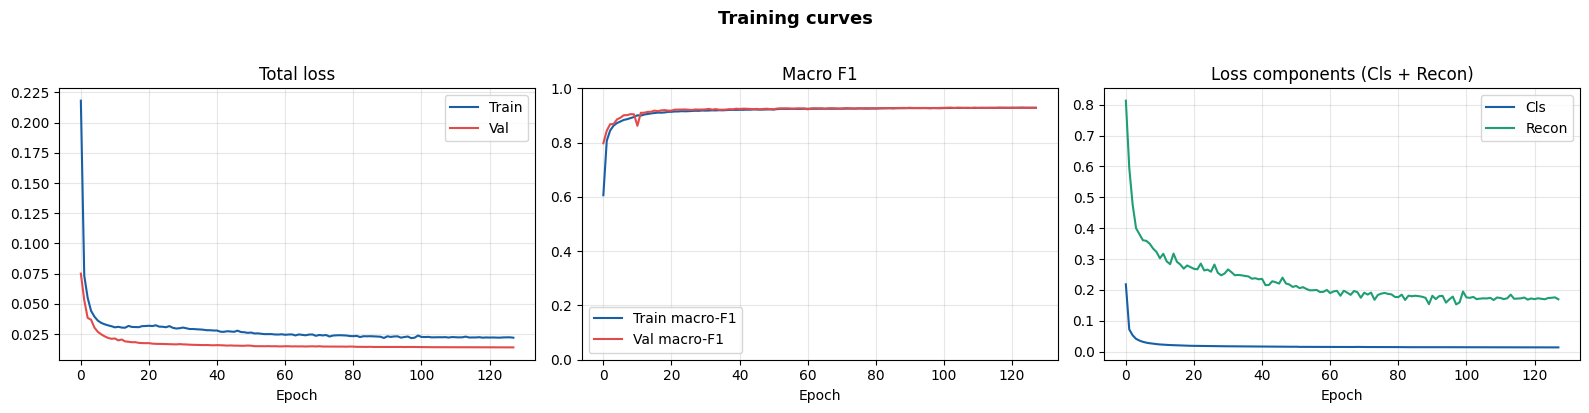

In [12]:
# =============================================================================
# 9. TRAINING CURVES
# =============================================================================

def plot_training_curves(hist, title="Training curves", save_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(hist['tr_loss'], label='Train', color='#185FA5')
    axes[0].plot(hist['va_loss'], label='Val',   color='#E24B4A')
    axes[0].set_title('Total loss'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(hist['tr_f1'], label='Train macro-F1', color='#185FA5')
    axes[1].plot(hist['va_f1'], label='Val macro-F1',   color='#E24B4A')
    axes[1].set_title('Macro F1'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(hist['tr_cls'], label='Cls',   color='#185FA5')
    axes[2].plot(hist['tr_rec'], label='Recon', color='#1D9E75')
    axes[2].set_title('Loss components (Cls + Recon)'); axes[2].set_xlabel('Epoch')
    axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_training_curves(hist, save_path=OUTPUT_DIR / "fig_training_curves.pdf")

In [13]:
# =============================================================================
# 10. INFERENCE
# =============================================================================

def run_inference(mdl, g: Data, BATCH: int = 32768):
    """Full-graph inference; returns preds, true, cls_conf, hybrid_score, embeds, rec_norm."""
    mdl.eval()
    g = g.to(DEVICE)
    full_ei = g.edge_index
    full_ea = g.edge_attr

    if INDUCTIVE:
        mp_ei = full_ei[:, g.train_edge_mask]
        mp_ea = full_ea[g.train_edge_mask]
    else:
        mp_ei, mp_ea = full_ei, full_ea

    all_logits, all_recon, all_embeds = [], [], []
    with torch.no_grad():
        for start in range(0, full_ei.size(1), BATCH):
            bids   = torch.arange(start, min(start + BATCH, full_ei.size(1)), device=DEVICE)
            b_ei   = full_ei[:, bids]
            b_ea   = full_ea[bids]
            lg, rc, _, re = mdl(g.x, mp_ei, mp_ea, target_ei=b_ei, target_ea=b_ea)
            all_logits.append(lg.cpu())
            all_recon.append(rc.cpu())
            all_embeds.append(re.cpu())

    logits_all = torch.cat(all_logits, dim=0)
    recon_all  = torch.cat(all_recon,  dim=0)
    embeds_all = torch.cat(all_embeds, dim=0).numpy().astype(np.float32)

    cls_conf = F.softmax(logits_all, dim=-1).max(-1).values.numpy()
    preds    = logits_all.argmax(-1).numpy()
    true_    = g.edge_y.cpu().numpy()

    ea_cpu  = g.edge_attr.cpu()
    rec_err = ((recon_all - ea_cpu).pow(2)).mean(-1).numpy()
    rec_z   = np.clip(
        (rec_err - mdl.rec_mean.item()) / (mdl.rec_std.item() + 1e-6), -5., 5.)
    rec_norm = 1.0 / (1.0 + np.exp(-rec_z))

    hybrid = 0.7 * cls_conf + 0.3 * rec_norm
    return preds, true_, cls_conf, hybrid, embeds_all, rec_norm


t = start_stage("Inference")
preds, true, cls_conf, hybrid_score, flow_embeds, rec_norm = run_inference(model, graph)

# Embedding health check
_e = flow_embeds[graph.test_edge_mask.cpu().numpy()]
_s = _e[np.random.RandomState(SEED).choice(len(_e), min(2000, len(_e)), replace=False)]
_sim = _s @ _s.T
print(f"Embedding diagnostics (n=2000 test sample):")
print(f"  std/dim : {_e.std(axis=0).mean():.4f}  (healthy >> 0.05)")
print(f"  mean sim: {_sim.mean():.4f}  (healthy < 0.90)")
del _e, _s, _sim
end_stage("Inference", t)

mask = graph.test_edge_mask.cpu().numpy()
print("=== TEST SET — best checkpoint ===")
print(classification_report(true[mask], preds[mask],
                             target_names=le.classes_, digits=4))


[START] Inference
Embedding diagnostics (n=2000 test sample):
  std/dim : 0.0706  (healthy >> 0.05)
  mean sim: 0.3421  (healthy < 0.90)
[END] Inference  |  00:00:08.11

=== TEST SET — best checkpoint ===
              precision    recall  f1-score   support

      Benign     0.9902    0.9891    0.9896    140000
    backdoor     0.9996    0.9983    0.9989      2353
        ddos     0.9786    0.9802    0.9794     28000
         dos     0.9380    0.9931    0.9647     14000
   injection     0.9160    0.8634    0.8889     14000
        mitm     0.7822    0.4385    0.5619      1081
    password     0.9536    0.9417    0.9476     16800
  ransomware     0.9876    0.9979    0.9927       480
    scanning     0.9775    0.9671    0.9723     42000
         xss     0.9425    0.9834    0.9625     28000

    accuracy                         0.9738    286714
   macro avg     0.9466    0.9153    0.9259    286714
weighted avg     0.9735    0.9738    0.9733    286714



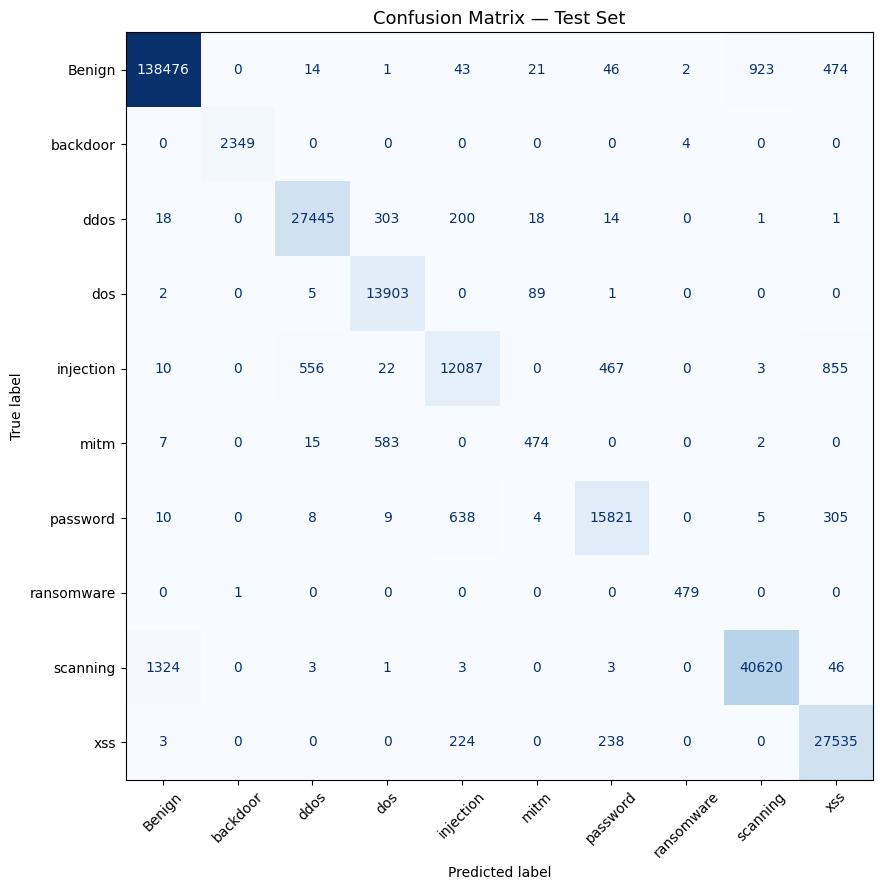

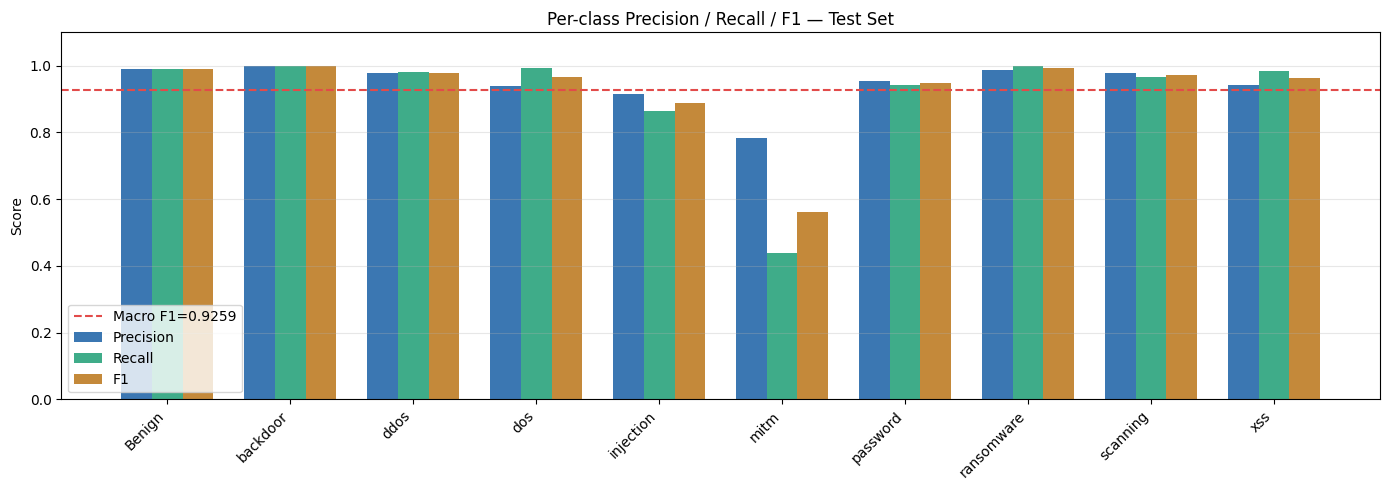

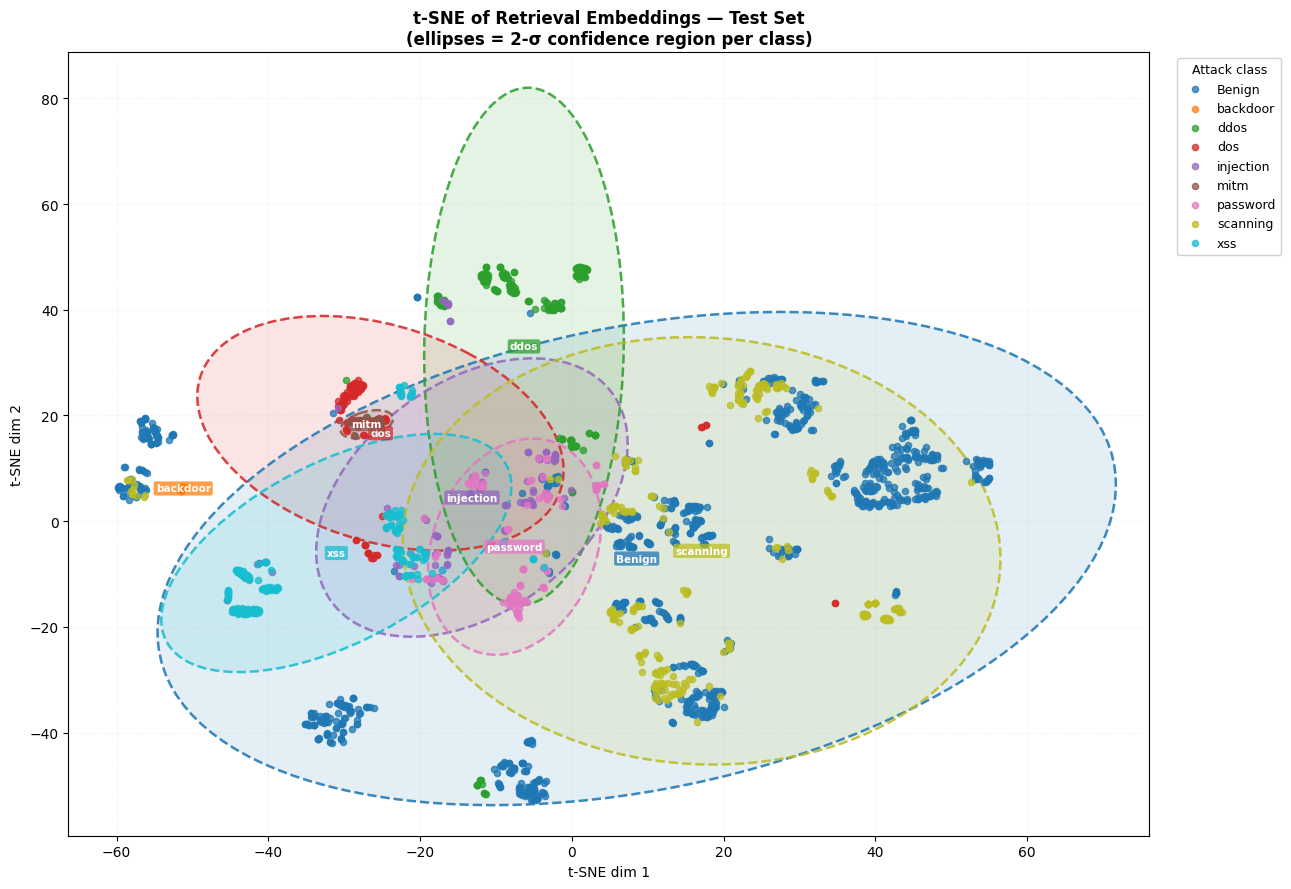

In [14]:
# =============================================================================
# 11. EVALUATION PLOTS
# =============================================================================

def plot_confusion_matrix(true_, preds_, mask_, classes, save_path=None):
    fig, ax = plt.subplots(figsize=(11, 9))
    cm = confusion_matrix(true_[mask_], preds_[mask_])
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(
        ax=ax, cmap='Blues', xticks_rotation=45, values_format='d', colorbar=False)
    plt.title("Confusion Matrix — Test Set", fontsize=13)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_f1_bars(true_, preds_, mask_, classes, save_path=None):
    rpt = classification_report(true_[mask_], preds_[mask_],
                                target_names=classes, output_dict=True, zero_division=0)
    x, w = np.arange(len(classes)), 0.25
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x-w, [rpt[c]['precision'] for c in classes], w, label='Precision', color='#185FA5', alpha=0.85)
    ax.bar(x,   [rpt[c]['recall']    for c in classes], w, label='Recall',    color='#1D9E75', alpha=0.85)
    ax.bar(x+w, [rpt[c]['f1-score']  for c in classes], w, label='F1',        color='#BA7517', alpha=0.85)
    ax.axhline(rpt['macro avg']['f1-score'], color='#E24B4A', ls='--', lw=1.5,
               label=f"Macro F1={rpt['macro avg']['f1-score']:.4f}")
    ax.set_xticks(x); ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.set_ylim(0, 1.1); ax.set_ylabel('Score'); ax.legend()
    ax.set_title('Per-class Precision / Recall / F1 — Test Set')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def _draw_confidence_ellipse(x_pts, y_pts, ax, color, n_std=2.0):
    """
    Draw a covariance-based confidence ellipse around a 2-D point cloud.

    Parameters
    ----------
    x_pts, y_pts : array-like   — coordinates of the cluster points
    ax            : Axes        — target axes
    color         : str         — face/edge colour (matched to scatter)
    n_std         : float       — number of std-devs that define the ellipse radius
                                  (2.0 ≈ 95 % of a bivariate normal distribution)
    """
    from matplotlib.patches import Ellipse
    import matplotlib.transforms as mtransforms

    if len(x_pts) < 3:          # need at least 3 points for a meaningful ellipse
        return

    cov  = np.cov(x_pts, y_pts)
    vals, vecs = np.linalg.eigh(cov)

    # largest eigenvector gives the ellipse orientation
    order  = vals.argsort()[::-1]
    vals   = vals[order]
    vecs   = vecs[:, order]
    angle  = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(np.abs(vals))

    ellipse = Ellipse(
        xy        = (np.mean(x_pts), np.mean(y_pts)),
        width     = width,
        height    = height,
        angle     = angle,
        facecolor = color,
        edgecolor = color,
        linewidth = 1.8,
        linestyle = '--',
        alpha     = 0.12,      # light fill
        zorder    = 1,
    )
    # crisp border on top of the fill
    border = Ellipse(
        xy        = (np.mean(x_pts), np.mean(y_pts)),
        width     = width,
        height    = height,
        angle     = angle,
        facecolor = 'none',
        edgecolor = color,
        linewidth = 1.8,
        linestyle = '--',
        alpha     = 0.85,
        zorder    = 2,
    )
    ax.add_patch(ellipse)
    ax.add_patch(border)


def plot_tsne(embeds, true_, mask_, classes, seed=42, n_samp=2000, save_path=None):
    from sklearn.manifold import TSNE
    import sklearn

    samp = np.random.RandomState(seed).choice(
        np.where(mask_)[0], min(n_samp, int(mask_.sum())), replace=False)

    kwargs = dict(n_components=2, random_state=seed,
                  perplexity=40, init='pca', learning_rate='auto')
    ver = tuple(int(x) for x in sklearn.__version__.split('.')[:2])
    kwargs['max_iter' if ver >= (1, 5) else 'n_iter'] = 1000

    emb2d    = TSNE(**kwargs).fit_transform(embeds[samp])
    labels_s = [classes[i] for i in true_[samp]]

    fig, ax  = plt.subplots(figsize=(13, 9))
    palette  = sns.color_palette('tab10', len(classes))

    for ci, cls in enumerate(classes):
        idx = [i for i, l in enumerate(labels_s) if l == cls]
        if not idx:
            continue
        color = palette[ci]
        pts   = emb2d[idx]

        # ── scatter points ────────────────────────────────────────────────
        ax.scatter(pts[:, 0], pts[:, 1],
                   label=cls, s=20, alpha=0.75,
                   color=color, zorder=3)

        # ── confidence ellipse (2-σ, ~95 %) ──────────────────────────────
        _draw_confidence_ellipse(pts[:, 0], pts[:, 1], ax, color=color, n_std=2.0)

        # ── class centroid label ──────────────────────────────────────────
        cx, cy = pts[:, 0].mean(), pts[:, 1].mean()
        ax.text(cx, cy, cls,
                fontsize=7.5, fontweight='bold',
                ha='center', va='center',
                color='white',
                bbox=dict(boxstyle='round,pad=0.2',
                          facecolor=color, edgecolor='none', alpha=0.75),
                zorder=5)

    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left',
              fontsize=9, framealpha=0.9,
              title='Attack class', title_fontsize=9)
    ax.set_title('t-SNE of Retrieval Embeddings — Test Set\n'
                 '(ellipses = 2-σ confidence region per class)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')
    ax.grid(alpha=0.2, linestyle=':')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_confusion_matrix(true, preds, mask, le.classes_,
                      save_path=OUTPUT_DIR / 'fig_confusion_matrix.pdf')
plot_f1_bars(true, preds, mask, le.classes_,
             save_path=OUTPUT_DIR / 'fig_f1_bars.pdf')
plot_tsne(flow_embeds, true, mask, le.classes_,
          save_path=OUTPUT_DIR / 'fig_tsne.pdf')

In [15]:
# =============================================================================
# 12. FAISS INDICES (dual: attack + benign)
# =============================================================================

# Built from training flows only: all attack flows, and a random subsample
# of up to 200,000 benign flows.
attack_mask_tr = (graph.train_edge_mask & (graph.edge_y != benign_class)).cpu()
attack_idx_arr = attack_mask_tr.nonzero(as_tuple=True)[0].numpy()
atk_embeds     = flow_embeds[attack_idx_arr].copy().astype(np.float32)
faiss.normalize_L2(atk_embeds)
attack_index   = faiss.IndexFlatIP(atk_embeds.shape[1])
attack_index.add(atk_embeds)
attack_meta    = df.iloc[attack_idx_arr].copy()
attack_meta['original_df_idx'] = attack_idx_arr
attack_meta    = attack_meta.reset_index(drop=True)

benign_mask_tr = (graph.train_edge_mask & (graph.edge_y == benign_class)).cpu()
benign_idx_arr = benign_mask_tr.nonzero(as_tuple=True)[0].numpy()
benign_idx_arr = np.random.RandomState(SEED).choice(
    benign_idx_arr, min(200_000, len(benign_idx_arr)), replace=False)
ben_embeds     = flow_embeds[benign_idx_arr].copy().astype(np.float32)
faiss.normalize_L2(ben_embeds)
benign_index   = faiss.IndexFlatIP(ben_embeds.shape[1])
benign_index.add(ben_embeds)
benign_meta    = df.iloc[benign_idx_arr].copy()
benign_meta['original_df_idx'] = benign_idx_arr
benign_meta    = benign_meta.reset_index(drop=True)

print(f"Attack index: {attack_index.ntotal:,} vectors")
print(f"Benign index: {benign_index.ntotal:,} vectors")

Attack index: 513,498 vectors
Benign index: 200,000 vectors


In [16]:
# =============================================================================
# 13. SUBGRAPH EXTRACTION
# =============================================================================

_node_to_edges: defaultdict = defaultdict(list)

def build_node_edge_index(df_: pd.DataFrame):
    global _node_to_edges
    _node_to_edges = defaultdict(list)
    for i, (s, d) in enumerate(zip(df_['src_idx'].values, df_['dst_idx'].values)):
        _node_to_edges[int(s)].append(i)
        _node_to_edges[int(d)].append(i)

build_node_edge_index(df)


def extract_flow_subgraph(flow_idx: int, df_: pd.DataFrame,
                           max_neighbors: int = 15) -> pd.DataFrame:
    row   = df_.iloc[flow_idx]
    seeds = {int(row['src_idx']), int(row['dst_idx'])}
    eids  = set()
    for node in seeds:
        eids.update(_node_to_edges[node])
    eids.add(flow_idx)
    eids = list(eids)
    if len(eids) > max_neighbors + 1:
        rng    = np.random.RandomState(SEED)
        others = [e for e in eids if e != flow_idx]
        eids   = rng.choice(others, min(max_neighbors, len(others)),
                             replace=False).tolist() + [flow_idx]
    return df_.iloc[eids]

In [17]:
# =============================================================================
# 14. FEATURE ATTRIBUTION (Gradient × Input)
# =============================================================================

def feature_attribution_local(flow_idx: int, mdl, g: Data,
                                sc: StandardScaler) -> np.ndarray:
    """Gradient × Input attribution on the local subgraph."""
    mdl.eval()
    dev     = next(mdl.parameters()).device
    nbr     = extract_flow_subgraph(flow_idx, df)
    nbr_idx = list(nbr.index)

    local_ea = torch.tensor(
        edge_feats_scaled[nbr_idx], dtype=torch.float32, device=dev
    ).clone().detach().requires_grad_(True)

    local_src = torch.tensor(df['src_idx'].values[nbr_idx], dtype=torch.long, device=dev)
    local_dst = torch.tensor(df['dst_idx'].values[nbr_idx], dtype=torch.long, device=dev)
    local_ei  = torch.stack([local_src, local_dst], dim=0)
    local_pos = nbr_idx.index(flow_idx)

    lg, _, _, _ = mdl(g.x.to(dev), local_ei, local_ea,
                      target_ei=local_ei, target_ea=local_ea)

    score = lg[local_pos, lg[local_pos].argmax()]
    grad  = torch.autograd.grad(score, local_ea)[0][local_pos]
    attr  = (grad * local_ea[local_pos]).abs()
    attr  = torch.nan_to_num(attr, nan=0., posinf=0., neginf=0.)

    # temporal-feature audit (paper Sec. 5.4)
    check_temporal_importance(attr.detach().cpu().numpy())

    return attr.detach().cpu().numpy()


def deletion_test_raw(flow_idx: int, mdl, g: Data, sc: StandardScaler,
                       top_n: int = 5,
                       precomputed_attr: np.ndarray = None) -> dict:
    """
    Drop in predicted-class probability after zeroing the top-n attributed
    features in raw space and re-standardising.
    """
    mdl.eval()
    dev  = next(mdl.parameters()).device
    attr = precomputed_attr if precomputed_attr is not None \
        else feature_attribution_local(flow_idx, mdl, g, sc)
    top  = np.argsort(attr)[-top_n:][::-1].astype(np.int64)

    full_ei = g.edge_index.to(dev)
    mp_ei   = full_ei[:, g.train_edge_mask.to(dev)] if INDUCTIVE else full_ei
    mp_ea   = g.edge_attr[g.train_edge_mask].to(dev) if INDUCTIVE else g.edge_attr.to(dev)
    q_ei    = full_ei[:, [flow_idx]]
    q_ea    = torch.tensor(edge_feats_scaled[[flow_idx]], dtype=torch.float32, device=dev)

    with torch.no_grad():
        lg, _, _, _ = mdl(g.x.to(dev), mp_ei, mp_ea, target_ei=q_ei, target_ea=q_ea)
    orig_pred  = int(lg[0].argmax().item())
    orig_score = float(F.softmax(lg[0], dim=-1)[orig_pred].item())

    ea_mod         = edge_feats_raw[[flow_idx]].copy()
    ea_mod[0, top] = 0.0
    q_ea_mod       = torch.tensor(sc.transform(ea_mod).astype(np.float32), device=dev)

    with torch.no_grad():
        new_lg, _, _, _ = mdl(g.x.to(dev), mp_ei, mp_ea,
                               target_ei=q_ei, target_ea=q_ea_mod)
    new_score = float(F.softmax(new_lg[0], dim=-1)[orig_pred].item())
    drop      = float(np.nan_to_num(orig_score - new_score, nan=0., posinf=0., neginf=0.))

    return {
        'orig_score':   orig_score,
        'masked_score': new_score,
        'score_drop':   drop,
        'top_feats':    [EDGE_FEATURE_COLS[i] for i in top],
    }


def aopc_curve(flow_idx: int, mdl, g: Data, sc: StandardScaler,
               max_k: int = 10,
               precomputed_attr: np.ndarray = None) -> tuple:
    """
    Area Over the Perturbation Curve: mean probability drop as the top-k
    attributed features are zeroed, k = 0..max_k.
    """
    mdl.eval()
    dev  = next(mdl.parameters()).device
    attr = precomputed_attr if precomputed_attr is not None \
        else feature_attribution_local(flow_idx, mdl, g, sc)
    sorted_feats = np.argsort(attr)[::-1].astype(np.int64)

    full_ei = g.edge_index.to(dev)
    mp_ei   = full_ei[:, g.train_edge_mask.to(dev)] if INDUCTIVE else full_ei
    mp_ea   = g.edge_attr[g.train_edge_mask].to(dev) if INDUCTIVE else g.edge_attr.to(dev)
    q_ei    = full_ei[:, [flow_idx]]
    q_ea    = torch.tensor(edge_feats_scaled[[flow_idx]], dtype=torch.float32, device=dev)

    with torch.no_grad():
        lg, _, _, _ = mdl(g.x.to(dev), mp_ei, mp_ea, target_ei=q_ei, target_ea=q_ea)
    orig_pred  = int(lg[0].argmax().item())
    orig_score = float(F.softmax(lg[0], dim=-1)[orig_pred].item())

    drops        = [0.0]
    ea_raw_query = edge_feats_raw[[flow_idx]].copy()

    for k in range(1, min(max_k + 1, len(sorted_feats))):
        ea_mod        = ea_raw_query.copy()
        ea_mod[0, sorted_feats[:k]] = 0.0
        ea_sc = torch.tensor(sc.transform(ea_mod).astype(np.float32), device=dev)
        with torch.no_grad():
            lg2, _, _, _ = mdl(g.x.to(dev), mp_ei, mp_ea,
                                target_ei=q_ei, target_ea=ea_sc)
        sc_k = float(F.softmax(lg2[0], dim=-1)[orig_pred].item())
        drops.append(orig_score - sc_k)

    return float(np.mean(drops)), drops


[START] Faithfulness Evaluation
Computing faithfulness metrics (n=100) ...

Faithfulness (top-5 deletion, n=100):
  mean drop  : 0.3898 ± 0.3492
  median drop: 0.3430
  >=0.10 frac: 72.00%
  >=0.30 frac: 53.00%
  <0.05  frac: 25.00%

[Table 16] NF-ToN-IoT-v2:
  Top-5 deletion drop (mean)   : 0.3898
  Top-5 deletion drop (median) : 0.3430
  AOPC (mean)                  : 0.2953
  Flows with drop < 0.05       : 25.00%

AOPC (area over perturbation curve):
  mean AOPC  : 0.2953 ± 0.2479
[END] Faithfulness Evaluation  |  00:01:50.38



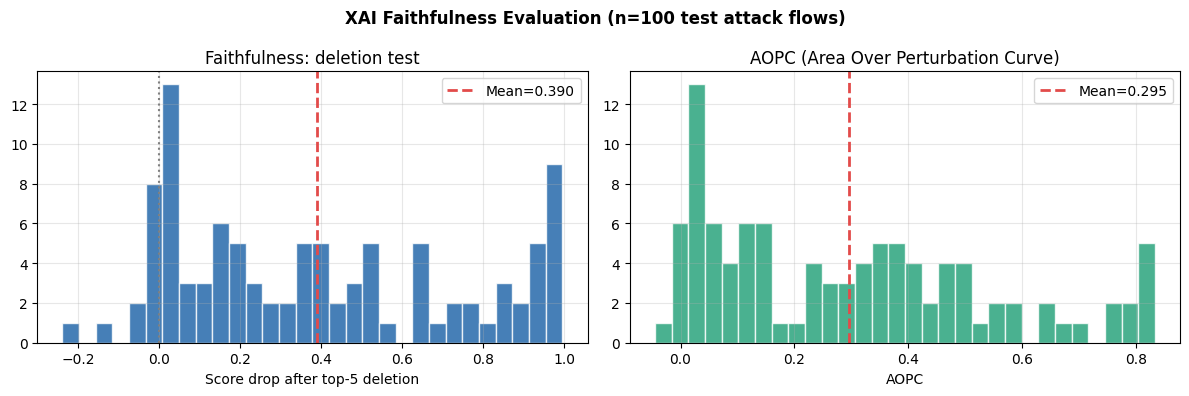

In [18]:
# =============================================================================
# 15. FAITHFULNESS EVALUATION
# =============================================================================

t = start_stage("Faithfulness Evaluation")
test_attack_idx = (graph.test_edge_mask & (graph.edge_y != benign_class)
                   ).nonzero(as_tuple=True)[0].cpu().numpy()

print("Computing faithfulness metrics (n=100) ...")
sample_fi  = np.random.RandomState(SEED).choice(test_attack_idx, 100, replace=False)
drops_top5 = []
aopc_vals  = []

for fi in sample_fi:
    fi   = int(fi)
    # attribution computed once and reused by both tests
    attr = feature_attribution_local(fi, model, graph, scaler)
    d    = deletion_test_raw(fi, model, graph, scaler, top_n=5, precomputed_attr=attr)
    drops_top5.append(d['score_drop'])
    aopc, _ = aopc_curve(fi, model, graph, scaler, max_k=8, precomputed_attr=attr)
    aopc_vals.append(aopc)

drops_top5 = np.array(drops_top5)
aopc_vals  = np.array(aopc_vals)
print(f"\nFaithfulness (top-5 deletion, n=100):")
print(f"  mean drop  : {drops_top5.mean():.4f} ± {drops_top5.std():.4f}")
print(f"  median drop: {np.median(drops_top5):.4f}")
print(f"  >=0.10 frac: {(drops_top5 >= 0.10).mean():.2%}")
print(f"  >=0.30 frac: {(drops_top5 >= 0.30).mean():.2%}")
frac_drop_lt_005 = (drops_top5 < 0.05).mean()
print(f"  <0.05  frac: {frac_drop_lt_005:.2%}")

print("\n[Table 16] NF-ToN-IoT-v2:")
print(f"  Top-5 deletion drop (mean)   : {drops_top5.mean():.4f}")
print(f"  Top-5 deletion drop (median) : {np.median(drops_top5):.4f}")
print(f"  AOPC (mean)                  : {aopc_vals.mean():.4f}")
print(f"  Flows with drop < 0.05       : {frac_drop_lt_005:.2%}")
print(f"\nAOPC (area over perturbation curve):")
print(f"  mean AOPC  : {aopc_vals.mean():.4f} ± {aopc_vals.std():.4f}")
end_stage("Faithfulness Evaluation", t)


def plot_faithfulness(drops, aopc_vals_, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(drops, bins=30, color='#185FA5', alpha=0.8, edgecolor='white')
    axes[0].axvline(drops.mean(), color='#E24B4A', ls='--', lw=2,
                    label=f'Mean={drops.mean():.3f}')
    axes[0].axvline(0, color='gray', ls=':')
    axes[0].set_xlabel('Score drop after top-5 deletion')
    axes[0].set_title('Faithfulness: deletion test')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].hist(aopc_vals_, bins=30, color='#1D9E75', alpha=0.8, edgecolor='white')
    axes[1].axvline(aopc_vals_.mean(), color='#E24B4A', ls='--', lw=2,
                    label=f'Mean={aopc_vals_.mean():.3f}')
    axes[1].set_xlabel('AOPC')
    axes[1].set_title('AOPC (Area Over Perturbation Curve)')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.suptitle('XAI Faithfulness Evaluation (n=100 test attack flows)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_faithfulness(drops_top5, aopc_vals,
                  save_path=OUTPUT_DIR / 'fig_faithfulness.pdf')

In [19]:
# =============================================================================
# 16. RAG RETRIEVAL
# =============================================================================

def mmr_rerank(scores: np.ndarray, embeds: np.ndarray,
               query_emb: np.ndarray, lambda_: float = 0.5, k: int = 3) -> list:
    """Maximal Marginal Relevance re-ranking for retrieval diversity."""
    selected, remaining = [], list(range(len(scores)))
    while len(selected) < k and remaining:
        if not selected:
            best = max(remaining, key=lambda i: scores[i])
        else:
            def mmr_score(i, sel=selected):
                rel = scores[i]
                red = max(float(np.dot(embeds[i], embeds[j])) for j in sel)
                return lambda_ * rel - (1 - lambda_) * red
            best = max(remaining, key=mmr_score)
        selected.append(best)
        remaining.remove(best)
    return selected


def retrieve_top_k(flow_idx: int, pred_class: int, k: int = 3):
    q = flow_embeds[flow_idx:flow_idx + 1].copy().astype(np.float32)
    faiss.normalize_L2(q)
    if le.classes_[pred_class] == 'Benign':
        scores, idxs = benign_index.search(q, k * 3)
        meta, emb    = benign_meta, ben_embeds
    else:
        scores, idxs = attack_index.search(q, k * 3)
        meta, emb    = attack_meta, atk_embeds
    idxs, scores = idxs[0], scores[0]
    valid        = idxs >= 0
    idxs, scores = idxs[valid], scores[valid]
    if len(idxs) == 0:
        return meta.iloc[[]], np.array([])
    sel = mmr_rerank(scores, emb[idxs], q[0], k=min(k, len(idxs)))
    return meta.iloc[idxs[sel]], scores[sel]

In [20]:
# =============================================================================
# 16b. TRIPLE SERIALIZATION HELPERS
# =============================================================================

_SAFE_INT_WARNED: set = set()

def _safe_int(row, col: str) -> int:
    val = row.get(col, None)
    if val is None:
        if col not in _SAFE_INT_WARNED:
            print(f"[WARN] serialize_to_triples: column '{col}' missing — defaulting 0")
            _SAFE_INT_WARNED.add(col)
        return 0
    return int(val)


def serialize_to_triples(flow_row, nbr_rows: pd.DataFrame) -> list:
    si  = int(flow_row['src_idx'])
    di  = int(flow_row['dst_idx'])
    fid = "flow:QUERY"
    svc = (f"service:port_{_safe_int(flow_row, 'L4_DST_PORT')}"
           f"_proto_{_safe_int(flow_row, 'PROTOCOL')}")
    triples = [
        (f"host:H{si}", "initiates",   fid),
        (fid,           "targets",     svc),
        (svc,           "hosted_on",   f"host:H{di}"),
        (fid,           "duration_ms", _safe_int(flow_row, 'FLOW_DURATION_MILLISECONDS')),
        (fid,           "in_bytes",    _safe_int(flow_row, 'IN_BYTES')),
        (fid,           "out_bytes",   _safe_int(flow_row, 'OUT_BYTES')),
        (fid,           "in_pkts",     _safe_int(flow_row, 'IN_PKTS')),
        (fid,           "out_pkts",    _safe_int(flow_row, 'OUT_PKTS')),
        (fid,           "tcp_flags",   _safe_int(flow_row, 'TCP_FLAGS')),
        (fid,           "l7_proto",    float(flow_row.get('L7_PROTO', 0))),
        (fid,           "min_ttl",     _safe_int(flow_row, 'MIN_TTL')),
        (fid,           "max_ttl",     _safe_int(flow_row, 'MAX_TTL')),
    ]
    n_atk = int((nbr_rows['Label'] == 1).sum()) if 'Label' in nbr_rows.columns else 0
    triples += [
        (f"host:H{si}", "neighborhood_size",         len(nbr_rows)),
        (f"host:H{si}", "neighborhood_attack_count", n_atk),
    ]
    return triples


def triples_to_text(t: list) -> str:
    return "\n".join(f"({s}, {p}, {o})" for s, p, o in t)

In [21]:
# =============================================================================
# 17. STRUCTURED PROMPT BUILDER AND LLM CALL
# =============================================================================

CONF_THRESHOLD   = 0.65
HYBRID_THRESHOLD = 0.60
OLLAMA_MODEL     = "llama3.2:3b"


def should_escalate(flow_idx: int) -> bool:
    return (
        float(cls_conf[flow_idx]) < CONF_THRESHOLD and
        float(hybrid_score[flow_idx]) < HYBRID_THRESHOLD
    )


def build_structured_prompt(
    flow_idx: int,
    k: int = 3,
    precomputed_attr: np.ndarray = None
) -> tuple:
    """
    Build the evidence-grounded JSON prompt for one flow.

    The query flow and k retrieved precedents are serialised as triples; the
    top-k attributed features are listed with importance and raw value; the
    deletion-test result is reported; epoch-timestamp columns are marked as
    non-citable. Returns the prompt plus the evidence used by the audit.
    """

    flow_row = df.iloc[flow_idx]
    nbr = extract_flow_subgraph(flow_idx, df)

    query_triples = serialize_to_triples(flow_row, nbr)
    q_text = triples_to_text(query_triples)

    retrieved, sims = retrieve_top_k(
        flow_idx,
        int(preds[flow_idx]),
        k=k
    )

    retrieved = retrieved.reset_index()

    blocks = []
    prec_labels = []

    for i, (_, r) in enumerate(retrieved.iterrows()):

        r_idx = int(r["index"])

        r_tri = serialize_to_triples(
            df.iloc[r_idx],
            extract_flow_subgraph(r_idx, df)
        )

        blocks.append(
            "PRECEDENT_" + str(i + 1) +
            " (similarity=" + str(round(float(sims[i]), 3)) +
            ", label=" + str(r["Attack"]) + "):\n" +
            triples_to_text(r_tri)
        )

        prec_labels.append(r["Attack"])

    pred_class = le.classes_[preds[flow_idx]]
    confidence = float(cls_conf[flow_idx])
    h_score = float(hybrid_score[flow_idx])

    attr = (
        precomputed_attr
        if precomputed_attr is not None
        else feature_attribution_local(
            flow_idx,
            model,
            graph,
            scaler
        )
    )

    top_feats_idx = (
        np.argsort(attr)[-k:][::-1].astype(np.int64)
    )

    top_feat_list = [
        {
            "feature": EDGE_FEATURE_COLS[i],
            "importance": round(float(attr[i]), 4)
        }
        for i in top_feats_idx
    ]

    # -------------------------------------------------------------------------
    # Attribution block: importance and raw value, labelled separately
    # -------------------------------------------------------------------------

    top_feats_lines = []

    for d in top_feat_list:

        fname = d["feature"]
        fidx = EDGE_FEATURE_COLS.index(fname)

        raw_val = round(
            float(edge_feats_raw[flow_idx, fidx]),
            4
        )

        top_feats_lines.append(
            f"- {fname}: "
            f"importance={d['importance']} "
            f"| raw_value={raw_val}"
        )

    top_feats_text = "\n".join(top_feats_lines)

    # -------------------------------------------------------------------------
    # Dedicated raw-values block for numeric claims
    # -------------------------------------------------------------------------

    raw_values_lines = []

    for d in top_feat_list:

        fname = d["feature"]

        if fname in NUMERIC_CHECK_EXCLUDE:

            raw_values_lines.append(
                f"- {fname}: "
                f"[epoch timestamp — do not cite as a numeric value]"
            )

        else:

            fidx = EDGE_FEATURE_COLS.index(fname)

            raw_val = round(
                float(edge_feats_raw[flow_idx, fidx]),
                4
            )

            raw_values_lines.append(
                f"- {fname}: {raw_val}"
            )

    raw_values_text = "\n".join(raw_values_lines)

    # -------------------------------------------------------------------------
    # Plain list of ALL valid source names for the LLM
    # Prevents paraphrasing of feature names
    # -------------------------------------------------------------------------

    all_valid_sources_text = ", ".join(
        d["feature"]
        for d in top_feat_list
        if d["feature"] not in NUMERIC_CHECK_EXCLUDE
    ) + ", classifier_confidence, hybrid_score"

    # -------------------------------------------------------------------------
    # Deletion test
    # -------------------------------------------------------------------------

    di = deletion_test_raw(
        flow_idx,
        model,
        graph,
        scaler,
        top_n=k,
        precomputed_attr=attr
    )

    del_text = (
        "score_drop=" +
        str(round(di["score_drop"], 4)) +
        " after removing " +
        str(di["top_feats"])
    )

    # -------------------------------------------------------------------------
    # Uncertainty handling
    # -------------------------------------------------------------------------

    uncertain = (
        confidence < CONF_THRESHOLD or
        h_score < HYBRID_THRESHOLD
    )

    unc_note = (
        "ALERT: LOW CONFIDENCE PREDICTION. "
        "You MUST add an UNCERTAINTY_FLAG "
        "section explaining why. "
        "Do NOT assign a definitive label.\n"
        if uncertain else ""
    )

    conf_str = "{:.4f}".format(confidence)
    hybrid_str = "{:.4f}".format(h_score)

    # -------------------------------------------------------------------------
    # Final prompt
    # -------------------------------------------------------------------------

    prompt = (

        "You are an IDS explanation engine. "
        "Respond ONLY with valid JSON.\n"
        "No markdown, no code fences, no preamble.\n\n"

        + unc_note +

        "GROUND TRUTH DATA "
        "(you may ONLY cite values from this section):\n\n"

        "QUERY FLOW:\n" +
        q_text + "\n\n"

        "PREDICTED CLASS: " +
        pred_class + "\n"

        "classifier_confidence: " +
        conf_str + "\n"

        "hybrid_score: " +
        hybrid_str + "\n\n"

        "TOP FEATURES "
        "(attribution importance scores — these are NOT raw values):\n" +
        top_feats_text + "\n\n"

        "FLOW RAW VALUES — "
        "cite THESE numbers in evidence_list, "
        "not the importance scores:\n" +
        raw_values_text + "\n\n"

        "DELETION TEST:\n" +
        del_text + "\n\n"

        "RETRIEVED PRECEDENTS:\n" +
        "\n".join(blocks) + "\n\n"

        "OUTPUT — respond with exactly this JSON schema:\n"

        "{\n"
        '  "predicted_class": '
        '"<string — must equal ' + pred_class + '>",\n'

        '  "rationale": '
        '"<2-3 sentences citing feature names '
        'and their RAW VALUES from FLOW RAW VALUES above>",\n'

        '  "counterfactual": '
        '"<1 sentence: name ONE feature, '
        'state its current RAW VALUE, '
        'and what value would change the prediction>",\n'

        '  "confidence_level": '
        "<float 0.0-1.0>,\n"

        '  "confidence_justification": '
        '"<1 sentence citing '
        'classifier_confidence=' + conf_str +
        ' and hybrid_score=' + hybrid_str + '>",\n'

        '  "evidence_list": [\n'

        '    {\n'
        '      "claim": "<short claim>",\n'
        '      "source": "<EXACT column name from this list: '
        + all_valid_sources_text + '>",\n'
        '      "value": "<raw value from FLOW RAW VALUES>"\n'
        '    }\n'

        '  ],\n'

        '  "uncertainty_flag": '
        '"<null OR reason string if confidence < 0.65 '
        'or hybrid < 0.60>"\n'

        "}\n\n"

        "STRICT RULES:\n"

        '- In evidence_list "source", '
        "copy the column name EXACTLY as written above "
        '(e.g. TCP_FLAGS not "tcp flags", '
        'L4_DST_PORT not "destination port").\n'

        '- In evidence_list "value" fields, '
        "always use the number from FLOW RAW VALUES, "
        "never the importance score.\n"

        '- Do NOT cite columns marked '
        "[epoch timestamp] as numeric values "
        "in evidence_list.\n"

        "- Do not invent feature values, "
        "similarity scores, or class labels "
        "not present above.\n"

        "- predicted_class must be exactly: " +
        pred_class + "\n"

        "- confidence_level must be between 0.0 and 1.0\n"

        "- Do NOT use external cybersecurity knowledge. "
        "Cite only values from this prompt.\n"
    )

    return (
        prompt,
        top_feat_list,
        di,
        prec_labels,
        confidence,
        h_score,
        uncertain,
        attr
    )


def call_llm_structured(
    prompt: str,
    model_name: str = OLLAMA_MODEL
) -> tuple:
    """
    Call Ollama (primary) / Anthropic (fallback),
    parse JSON response.

    Returns:
        (
            parsed_dict_or_None,
            raw_text,
            source
        )
    """

    import requests

    payload = {
        "model": model_name,
        "prompt": prompt,
        "system": (
            "You are an IDS explanation engine. "
            "Respond ONLY with valid JSON "
            "matching the schema given. "
            "No markdown, no code fences."
        ),
        "stream": False,
        "options": {
            "temperature": 0.1,
            "top_p": 0.9
        },
    }

    raw_text = None
    source = "none"

    # -------------------------------------------------------------------------
    # Primary: Ollama
    # -------------------------------------------------------------------------

    try:

        r = requests.post(
            "http://localhost:11434/api/generate",
            json=payload,
            timeout=120
        )

        if r.status_code == 200:

            raw_text = (
                r.json()
                .get("response", "")
                .strip()
            )

            source = "ollama"

    except Exception as e:

        print(f"    [Ollama failed: {e}]")

    # -------------------------------------------------------------------------
    # Fallback: Anthropic
    # -------------------------------------------------------------------------

    if not raw_text:

        try:

            import anthropic

            client = anthropic.Anthropic()

            msg = client.messages.create(
                model="claude-sonnet-4-6",
                max_tokens=1500,

                system=(
                    "You are an IDS explanation engine. "
                    "Respond ONLY with valid JSON. "
                    "No markdown, no code fences."
                ),

                messages=[
                    {
                        "role": "user",
                        "content": prompt
                    }
                ]
            )

            raw_text = msg.content[0].text.strip()
            source = "anthropic"

        except Exception as e:

            print(f"    [Anthropic failed: {e}]")

    # -------------------------------------------------------------------------
    # Total failure
    # -------------------------------------------------------------------------

    if not raw_text:
        return None, "", "none"

    # -------------------------------------------------------------------------
    # Cleanup markdown fences if model ignored instructions
    # -------------------------------------------------------------------------

    clean = re.sub(
        r"^```(?:json)?\s*",
        "",
        raw_text.strip(),
        flags=re.MULTILINE
    )

    clean = re.sub(
        r"```\s*$",
        "",
        clean.strip(),
        flags=re.MULTILINE
    )

    # -------------------------------------------------------------------------
    # Strict parse
    # -------------------------------------------------------------------------

    try:

        return (
            json.loads(clean),
            raw_text,
            source
        )

    except json.JSONDecodeError:

        match = re.search(
            r"\{.*\}",
            clean,
            re.DOTALL
        )

        if match:

            try:

                return (
                    json.loads(match.group()),
                    raw_text,
                    source
                )

            except Exception:
                pass

    return None, raw_text, source

In [22]:
# =============================================================================
# 18. GROUNDING AUDIT AND TEXT-QUALITY METRICS
# =============================================================================

try:
    from rouge_score import rouge_scorer
    ROUGE_AVAILABLE = True
except ImportError:
    ROUGE_AVAILABLE = False
    print('[WARNING] rouge-score not installed. pip install rouge-score')

try:
    from bert_score import score as bert_score_fn
    BERT_SCORE_AVAILABLE = True
except ImportError:
    BERT_SCORE_AVAILABLE = False
    print('[WARNING] bert-score not installed. pip install bert-score')

try:
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    BLEU_AVAILABLE = True
except ImportError:
    BLEU_AVAILABLE = False
    print('[WARNING] nltk not installed. pip install nltk')

print(f'ROUGE: {ROUGE_AVAILABLE} | BERTScore: {BERT_SCORE_AVAILABLE} | BLEU: {BLEU_AVAILABLE}')


def detect_hallucinations(parsed: Optional[dict], flow_idx: int,
                           top_feat_list: list, prec_labels: list,
                           pred_class: str) -> dict:
    """
    Grounding audit of one parsed explanation.

    Implementation name     Paper name (Sec. 3.8)
      H1_label            -> S1  predicted_class equals the detector prediction
      H2_conf_range       -> S2  confidence_level lies in [0, 1]
      H3_feature_grounded -> H1  evidence sources are real feature / triple names
      H4_numeric_faithful -> H2  cited raw values match the flow within max(10%, 1.0)
      H5_prec_label       -> H3  class names cited in rationale/counterfactual are the
                                 prediction or a retrieved precedent label
                                 (case-insensitive substring match)

    hallucination_score is the fraction of the five checks that fail. The paper's
    content-only score (H1-H3) equals this value x 5/3 when both schema gates pass.
    Unparseable output receives a score of 1.0.
    """
    if parsed is None:
        return {
            'H1_label': False, 'H2_conf_range': False,
            'H3_feature_grounded': False, 'H4_numeric_faithful': False,
            'H5_prec_label': False,
            'hallucination_score': 1.0,
            'details': ['JSON parse failed — all checks skipped'],
        }

    checks, details = {}, []
    flow_row = df.iloc[flow_idx]

    # H1 (paper S1): predicted_class must match the detector prediction
    json_pred = parsed.get('predicted_class', '')
    h1_ok = (str(json_pred).strip().lower() == pred_class.strip().lower())
    checks['H1_label'] = h1_ok
    if not h1_ok:
        details.append(f'H1 FAIL: JSON predicted_class={json_pred!r} != GNN pred={pred_class!r}')

    # H2 (paper S2): confidence_level in [0, 1]
    conf_val = parsed.get('confidence_level', -1)
    h2_ok = isinstance(conf_val, (int, float)) and 0.0 <= float(conf_val) <= 1.0
    checks['H2_conf_range'] = h2_ok
    if not h2_ok:
        details.append(f'H2 FAIL: confidence_level={conf_val} out of [0,1]')

    # H3 (paper H1): evidence sources are real feature names / triple predicates
    valid_sources = set(EDGE_FEATURE_COLS) | {
        'in_bytes', 'out_bytes', 'in_pkts', 'out_pkts', 'tcp_flags',
        'duration_ms', 'l7_proto', 'min_ttl', 'max_ttl',
        'neighborhood_size', 'neighborhood_attack_count',
        'classifier_confidence', 'hybrid_score', 'similarity',
    }

    # normalised variants (case, '_' vs ' ') for tolerant name matching
    valid_sources_lower = {v.lower().replace('_', ' ') for v in valid_sources} \
                        | {v.lower() for v in valid_sources}

    evidence    = parsed.get('evidence_list', [])
    bad_sources = []
    for ev in evidence:
        src = str(ev.get('source', '')).lower().strip()
        src_nospace = src.replace(' ', '_')   # "tcp flags" → "tcp_flags"
        src_nospace2 = src.replace('-', '_')  # "tcp-flags" → "tcp_flags"

        matched = (
            any(vs.lower() in src        or src        in vs.lower() for vs in valid_sources)
            or any(vs.lower() in src_nospace or src_nospace in vs.lower() for vs in valid_sources)
            or any(vs.lower() in src_nospace2 or src_nospace2 in vs.lower() for vs in valid_sources)
            or src in valid_sources_lower
            or src_nospace in valid_sources_lower
        )
        if not matched:
            bad_sources.append(src)

    h3_ok = len(bad_sources) == 0
    checks['H3_feature_grounded'] = h3_ok
    if not h3_ok:
        details.append(f'H3 FAIL: ungrounded sources: {bad_sources[:3]}')

    # H4 (paper H2): cited raw values match the flow within max(10%, 1.0).
    # Epoch-scale columns are skipped, as are values on the attribution-score
    # scale (0-2) cited for columns whose raw value exceeds 100.
    numeric_errors  = []
    numeric_skipped = []

    for ev in evidence:
        src     = str(ev.get('source', '')).strip()
        val_str = str(ev.get('value', '')).strip()

        if src not in EDGE_FEATURE_COLS:
            continue

        if src in NUMERIC_CHECK_EXCLUDE:
            numeric_skipped.append(src)
            continue

        try:
            cited_val  = float(re.sub(r'[^0-9.\-eE]', '', val_str))
            actual_val = float(flow_row.get(src, np.nan))

            if np.isnan(actual_val):
                continue

            # cited value is on the attribution-score scale, not the raw scale
            if 0.0 <= cited_val <= 2.0 and abs(actual_val) > 100:
                numeric_skipped.append(f'{src} (importance-vs-raw mismatch)')
                continue

            tol = max(abs(actual_val) * 0.10, 1.0)
            if abs(cited_val - actual_val) > tol:
                numeric_errors.append(
                    f'{src}: cited={cited_val}, actual={round(actual_val, 2)}')

        except (ValueError, TypeError):
            pass

    h4_ok = len(numeric_errors) == 0
    checks['H4_numeric_faithful'] = h4_ok
    if not h4_ok:
        details.append(f'H4 FAIL: numeric mismatches: {numeric_errors[:2]}')
    if numeric_skipped:
        details.append(f'H4 INFO: skipped {len(numeric_skipped)} excluded/mismatch cols')

    # H5 (paper H3): class names cited in the rationale/counterfactual must be
    # the prediction or a retrieved precedent label
    rationale      = parsed.get('rationale', '') + parsed.get('counterfactual', '')
    all_classes    = set(le.classes_)
    cited_classes  = {c for c in all_classes if c.lower() in rationale.lower()}
    allowed        = set(prec_labels) | {pred_class}
    phantom_labels = cited_classes - allowed
    h5_ok = len(phantom_labels) == 0
    checks['H5_prec_label'] = h5_ok
    if not h5_ok:
        details.append(f'H5 FAIL: cited classes not in precedents: {phantom_labels}')

    n_fail = sum(1 for v in checks.values() if not v)
    hallucination_score = n_fail / len(checks)

    return {**checks,
            'hallucination_score': hallucination_score,
            'details': details if details else ['All checks passed']}


def compute_text_metrics(explanation_text: str, reference_text: str) -> dict:
    if not explanation_text or len(explanation_text.strip()) < 10:
        return {'rouge_l': 0.0, 'bert_f1': 0.0, 'length_words': 0}

    metrics = {'length_words': len(explanation_text.split())}

    if ROUGE_AVAILABLE:
        scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
        score  = scorer.score(reference_text[:2000], explanation_text)
        metrics['rouge_l'] = round(score['rougeL'].fmeasure, 4)
    else:
        metrics['rouge_l'] = None

    if BERT_SCORE_AVAILABLE:
        try:
            P, R, F = bert_score_fn(
                [explanation_text], [reference_text[:512]],
                lang='en', verbose=False, model_type='distilbert-base-uncased')
            metrics['bert_f1'] = round(float(F[0]), 4)
        except Exception:
            metrics['bert_f1'] = None
    else:
        metrics['bert_f1'] = None

    return metrics


def compute_self_bleu(explanations: list) -> Optional[float]:
    if not BLEU_AVAILABLE or len(explanations) < 2:
        return None
    sf        = SmoothingFunction().method1
    tokenized = [e.lower().split() for e in explanations if e and len(e.split()) > 5]
    if len(tokenized) < 2:
        return None
    scores = []
    for i, hyp in enumerate(tokenized):
        refs = [t for j, t in enumerate(tokenized) if j != i]
        try:
            scores.append(sentence_bleu(refs, hyp, smoothing_function=sf))
        except Exception:
            pass
    return round(float(np.mean(scores)), 4) if scores else None

ROUGE: True | BERTScore: True | BLEU: True


> **Note.** The LLM-stage results in this notebook come from a second execution and are not the values of paper Tables 13–15 (those are in the main notebook).

In [23]:
# =============================================================================
# 19. LARGE-SCALE STRUCTURED LLM ANALYSIS
# =============================================================================

t = start_stage("Large-Scale Structured LLM Analysis")

FLOWS_PER_CLASS = 10
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

test_attack_df  = df.iloc[test_attack_idx].copy()
demo_flow_pairs = []
for name in le.classes_:
    if name == 'Benign':
        continue
    rows = test_attack_df[test_attack_df['Attack'] == name]
    if len(rows) == 0:
        continue
    n = min(FLOWS_PER_CLASS, len(rows))
    for fi in rows.sample(n, random_state=SEED).index.tolist():
        demo_flow_pairs.append((int(fi), name))

print(f'Flows selected for structured analysis: {len(demo_flow_pairs)}')

t_rag = time.time()
results_structured = []

for fi, true_class in demo_flow_pairs:
    pred_class_i = le.classes_[preds[fi]]
    conf_i       = float(cls_conf[fi])
    h_i          = float(hybrid_score[fi])
    escalated    = should_escalate(fi)

    row_result = {
        'flow_idx':     fi,
        'true_class':   true_class,
        'pred_class':   pred_class_i,
        'correct':      true_class == pred_class_i,
        'confidence':   conf_i,
        'hybrid':       h_i,
        'escalated':    escalated,
        'parsed':       None,
        'raw_text':     '',
        'llm_source':   'none',
        'hallucination': None,
        'text_metrics': {},
    }

    esc_tag = ' [ESCALATED]' if escalated else ''
    print(f'\n{"="*80}')
    print(f'Flow {fi:>8} | true={true_class:<12} pred={pred_class_i:<12}'
          f' conf={conf_i:.3f} hybrid={h_i:.3f}{esc_tag}')

    if escalated:
        row_result['raw_text'] = 'UNCERTAIN — flagged for human review'
        results_structured.append(row_result)
        print('  Warning: Skipping LLM — low confidence')
        continue

    try:
        # attribution computed once and reused for the prompt and deletion test;
        # k=3 precedents and the top-3 attributed features enter the prompt
        attr = feature_attribution_local(fi, model, graph, scaler)
        prompt, top_feat_list, di, prec_labels, _, _, uncertain, _ = \
            build_structured_prompt(fi, k=3, precomputed_attr=attr)

        t0 = time.time()
        parsed, raw_text, source = call_llm_structured(prompt, OLLAMA_MODEL)
        elapsed = time.time() - t0

        row_result['parsed']     = parsed
        row_result['raw_text']   = raw_text
        row_result['llm_source'] = source
        row_result['llm_time']   = round(elapsed, 2)

        hall = detect_hallucinations(parsed, fi, top_feat_list, prec_labels, pred_class_i)
        row_result['hallucination'] = hall

        ref_text  = ('class=' + pred_class_i +
                     ' features=' + str([d['feature'] for d in top_feat_list]) +
                     ' score_drop=' + str(round(di['score_drop'], 4)))
        expl_text = raw_text if parsed is None else (
            parsed.get('rationale', '') + ' ' + parsed.get('counterfactual', ''))
        row_result['text_metrics'] = compute_text_metrics(expl_text, ref_text)

        if parsed:
            print(f"  Rationale   : {parsed.get('rationale','')[:120]}...")
            print(f"  Counterfact : {parsed.get('counterfactual','')[:100]}")
            print(f"  Confidence  : {parsed.get('confidence_level','?')}")
            print(f"  Evidence    : {len(parsed.get('evidence_list', []))} items")

        hs  = hall['hallucination_score']
        rl  = row_result['text_metrics'].get('rouge_l', 'N/A')
        wc  = row_result['text_metrics'].get('length_words', '?')
        chk = [k + ':' + str(v)[:1] for k, v in hall.items() if k.startswith('H')]
        print(f'  Hall.score  : {hs:.2f} | checks: {chk}')
        print(f'  ROUGE-L     : {rl}  | words: {wc}')
        print(f'  LLM source  : {source}  ({elapsed:.1f}s)')

    except KeyboardInterrupt:
        print('\n[Interrupted — saving partial results]')
        break
    except Exception as ex:
        row_result['raw_text'] = f'[ERROR: {ex}]'
        print(f'  [Error: {ex}]')

    results_structured.append(row_result)

n_esc_total = sum(1 for r in results_structured if r['escalated'])
print(f'\nTotal time: {time.time()-t_rag:.1f}s  |  '
      f'Flows: {len(results_structured)}  |  Escalated: {n_esc_total}')

# ── Flatten into a DataFrame for aggregation ─────────────────────────────────
rows_flat = []
for r in results_structured:
    hall = r.get('hallucination') or {}
    tm   = r.get('text_metrics')  or {}
    rows_flat.append({
        'flow_idx':            r['flow_idx'],
        'true_class':          r['true_class'],
        'pred_class':          r['pred_class'],
        'correct':             r.get('correct', False),
        'confidence':          r['confidence'],
        'hybrid':              r['hybrid'],
        'escalated':           r['escalated'],
        'llm_source':          r.get('llm_source', 'none'),
        'llm_time':            r.get('llm_time', 0.0),
        'hall_score':          hall.get('hallucination_score', np.nan),
        'H1_label':            hall.get('H1_label', np.nan),
        'H2_conf_range':       hall.get('H2_conf_range', np.nan),
        'H3_feature_grounded': hall.get('H3_feature_grounded', np.nan),
        'H4_numeric_faithful': hall.get('H4_numeric_faithful', np.nan),
        'H5_prec_label':       hall.get('H5_prec_label', np.nan),
        'rouge_l':             tm.get('rouge_l', np.nan),
        'bert_f1':             tm.get('bert_f1', np.nan),
        'length_words':        tm.get('length_words', np.nan),
        'parse_success':       r.get('parsed') is not None,
    })

res_df       = pd.DataFrame(rows_flat)
explained_df = res_df[~res_df['escalated'] & res_df['parse_success']]

print('=' * 70)
print('AGGREGATE RESULTS SUMMARY')
print('=' * 70)
print(f'Total flows        : {len(res_df)}')
print(f'Escalated          : {res_df["escalated"].sum()} ({100*res_df["escalated"].mean():.1f}%)')
print(f'Successfully parsed: {res_df["parse_success"].sum()}')

if len(explained_df) > 0:
    print(f'\nHallucination (explained flows, n={len(explained_df)}):')
    print(f'  Mean hall. score : {explained_df["hall_score"].mean():.3f} '
          f'+/- {explained_df["hall_score"].std():.3f}')
    for col, label in [
        ('H1_label', 'Label pass'), ('H2_conf_range', 'Conf range'),
        ('H3_feature_grounded', 'Grounded'), ('H4_numeric_faithful', 'Numeric faith.'),
        ('H5_prec_label', 'Prec labels'),
    ]:
        if col in explained_df.columns:
            print(f'  {label:<20}: {explained_df[col].mean():.1%}')
    if explained_df['rouge_l'].notna().any():
        print(f'\nText quality:')
        print(f'  ROUGE-L mean     : {explained_df["rouge_l"].mean():.4f}')
    if explained_df['bert_f1'].notna().any():
        print(f'  BERTScore F1     : {explained_df["bert_f1"].mean():.4f}')
    print(f'  Avg word count   : {explained_df["length_words"].mean():.0f}')

expl_texts = []
for r in results_structured:
    if not r.get('escalated') and r.get('parsed'):
        txt = (r['parsed'].get('rationale', '') + ' ' +
               r['parsed'].get('counterfactual', ''))
        if txt.strip():
            expl_texts.append(txt)
self_bleu = compute_self_bleu(expl_texts)
if self_bleu is not None:
    print(f'\nSelf-BLEU (diversity, lower=better): {self_bleu:.4f}')

# ── Per-class explanation quality table ────────────────────────────────
if len(explained_df) > 0:
    per_class = explained_df.groupby('true_class').agg(
        n_flows         =('flow_idx',             'count'),
        n_correct       =('correct',               'sum'),
        mean_conf       =('confidence',            'mean'),
        mean_hybrid     =('hybrid',                'mean'),
        mean_hall_score =('hall_score',            'mean'),
        hall_rate       =('hall_score',            lambda x: (x > 0).mean()),
        grounding_rate  =('H3_feature_grounded',   'mean'),
        numeric_faith   =('H4_numeric_faithful',   'mean'),
        mean_rouge_l    =('rouge_l',                'mean'),
        mean_words      =('length_words',           'mean'),
        parse_rate      =('parse_success',          'mean'),
    ).reset_index()
    per_class['accuracy'] = per_class['n_correct'] / per_class['n_flows']
    per_class = per_class.sort_values('mean_hall_score', ascending=False)

    print('PER-CLASS EXPLANATION QUALITY TABLE')
    print('=' * 100)
    cols = ['true_class', 'n_flows', 'accuracy', 'mean_conf', 'mean_hall_score',
            'hall_rate', 'grounding_rate', 'numeric_faith', 'mean_rouge_l', 'mean_words']
    print(per_class[cols].round(3).to_string(index=False))
    per_class.to_csv(OUTPUT_DIR / 'per_class_explanation_quality.csv', index=False)
else:
    per_class = pd.DataFrame()
    print('No explained flows available for per-class table.')

end_stage("Large-Scale Structured LLM Analysis", t)


[START] Large-Scale Structured LLM Analysis
Flows selected for structured analysis: 90

Flow   500197 | true=backdoor     pred=backdoor     conf=0.958 hybrid=0.822


  Rationale   : The prediction is based on the similarity to the retrieved precedents, which all have a label of 'backdoor'. The feature...
  Counterfact : Changing the RAW VALUE of SRC_TO_DST_AVG_THROUGHPUT from 11520000.0 to 0 would likely change the pre
  Confidence  : 0.9583
  Evidence    : 3 items
  Hall.score  : 0.00 | checks: ['H1_label:T', 'H2_conf_range:T', 'H3_feature_grounded:T', 'H4_numeric_faithful:T', 'H5_prec_label:T']
  ROUGE-L     : 0.2857  | words: 59
  LLM source  : ollama  (11.1s)

Flow   826659 | true=backdoor     pred=backdoor     conf=0.977 hybrid=0.835
  Rationale   : The prediction is based on the similarity to Precedent_1, which has a high similarity score of 1.0 and matches the L7_PR...
  Counterfact : Changing the L7_PROTO feature from its current raw value of 131.0 to a different value would likely 
  Confidence  : 0.977
  Evidence    : 3 items
  Hall.score  : 0.00 | checks: ['H1_label:T', 'H2_conf_range:T', 'H3_feature_grounded:T', 'H4_numeric_faithful:T',

Saved: <output_dir>/fig_explanation_quality.pdf


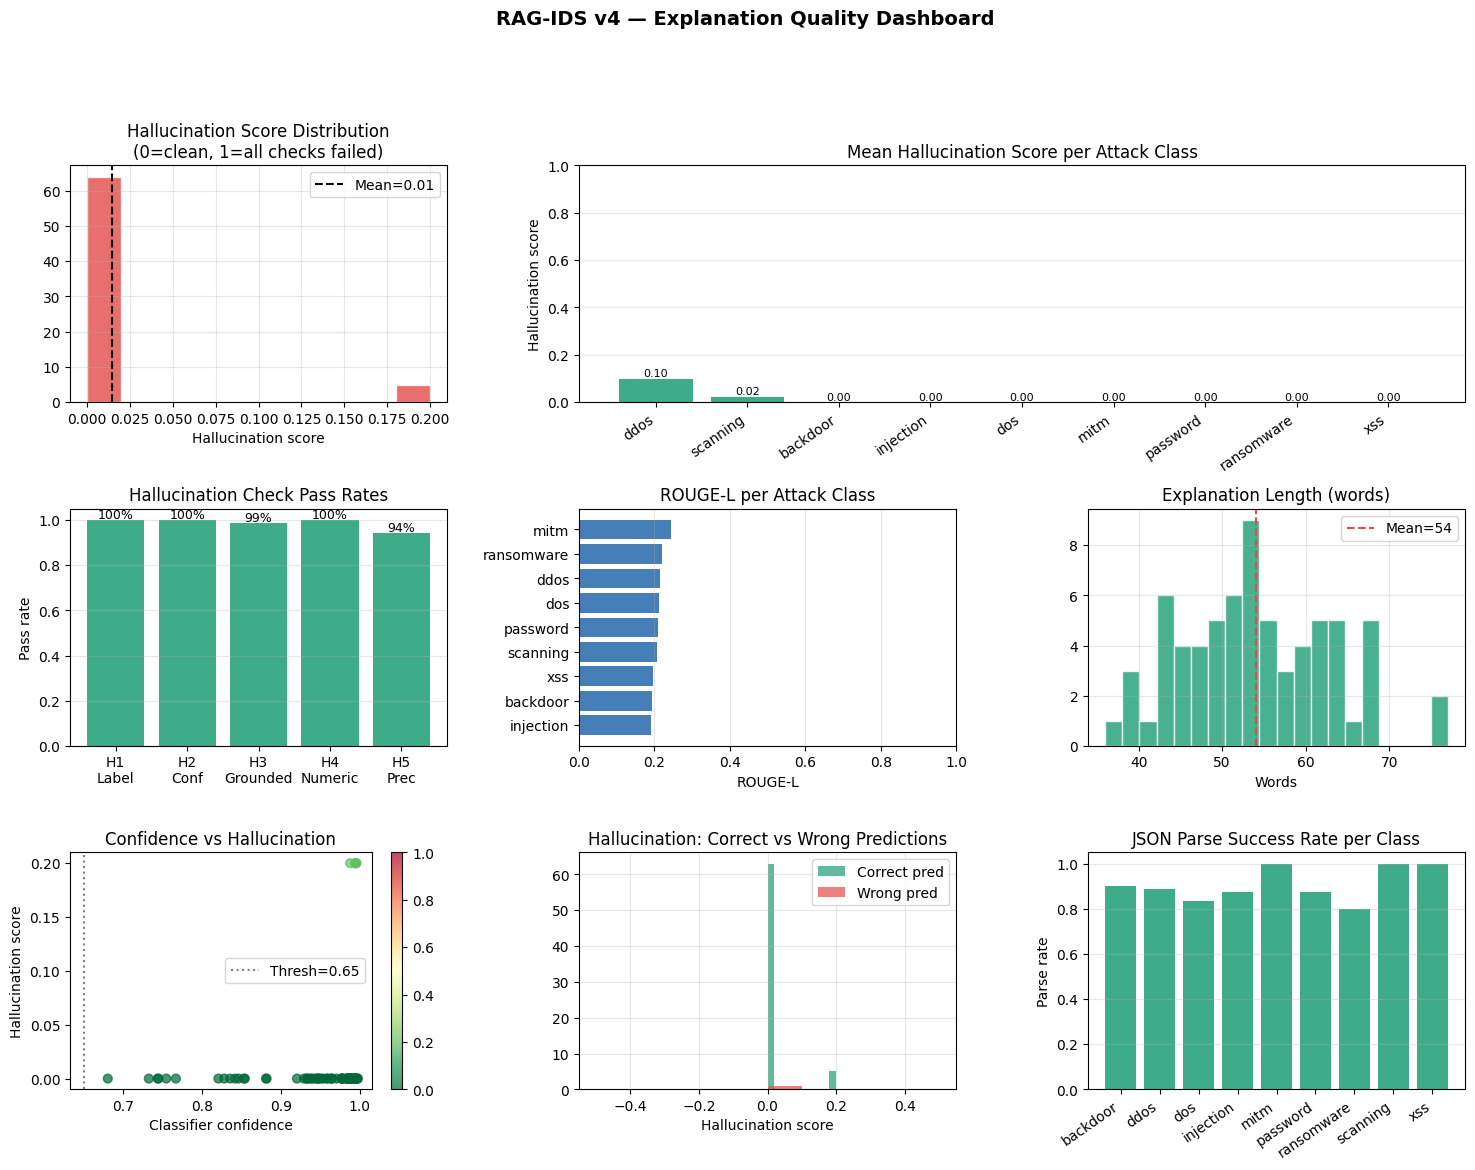

Markdown report saved -> <output_dir>/RAG_IDS_v4_Explanation_Report.md
JSON results saved -> <output_dir>/RAG_IDS_v4_Explanation_Results.json


In [24]:
# =============================================================================
# 19b. EXPLANATION QUALITY DASHBOARD + REPORT EXPORT
# =============================================================================

def plot_hallucination_dashboard(res_df_: pd.DataFrame, explained_df_: pd.DataFrame,
                                  save_path=None):
    if len(explained_df_) == 0:
        print('No explained flows to visualise.')
        return

    fig = plt.figure(figsize=(18, 12))
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.hist(explained_df_['hall_score'].dropna(), bins=10,
             color='#E24B4A', alpha=0.8, edgecolor='white')
    mean_h = explained_df_['hall_score'].mean()
    ax1.axvline(mean_h, color='black', ls='--', label=f'Mean={mean_h:.2f}')
    ax1.set_title('Hallucination Score Distribution\n(0=clean, 1=all checks failed)')
    ax1.set_xlabel('Hallucination score'); ax1.legend(); ax1.grid(alpha=0.3)

    ax2 = fig.add_subplot(gs[0, 1:])
    pc   = explained_df_.groupby('true_class')['hall_score'].mean().sort_values(ascending=False)
    clrs = ['#E24B4A' if v > 0.3 else '#BA7517' if v > 0.1 else '#1D9E75' for v in pc.values]
    ax2.bar(pc.index, pc.values, color=clrs, alpha=0.85)
    ax2.set_title('Mean Hallucination Score per Attack Class')
    ax2.set_ylabel('Hallucination score'); ax2.set_ylim(0, 1)
    ax2.set_xticklabels(pc.index, rotation=35, ha='right')
    ax2.grid(axis='y', alpha=0.3)
    for i, (cls, val) in enumerate(pc.items()):
        ax2.text(i, val + 0.01, f'{val:.2f}', ha='center', fontsize=8)

    ax3 = fig.add_subplot(gs[1, 0])
    check_cols  = ['H1_label', 'H2_conf_range', 'H3_feature_grounded',
                   'H4_numeric_faithful', 'H5_prec_label']
    check_names = ['H1\nLabel', 'H2\nConf', 'H3\nGrounded', 'H4\nNumeric', 'H5\nPrec']
    pass_rates  = [explained_df_[c].mean() for c in check_cols if c in explained_df_.columns]
    clrs3 = ['#1D9E75' if p > 0.8 else '#BA7517' if p > 0.5 else '#E24B4A' for p in pass_rates]
    ax3.bar(check_names[:len(pass_rates)], pass_rates, color=clrs3, alpha=0.85)
    ax3.set_title('Hallucination Check Pass Rates')
    ax3.set_ylabel('Pass rate'); ax3.set_ylim(0, 1.05)
    for i, p in enumerate(pass_rates):
        ax3.text(i, p + 0.01, f'{p:.0%}', ha='center', fontsize=9)
    ax3.grid(axis='y', alpha=0.3)

    ax4 = fig.add_subplot(gs[1, 1])
    if explained_df_['rouge_l'].notna().any():
        rg = explained_df_.groupby('true_class')['rouge_l'].mean().sort_values()
        ax4.barh(rg.index, rg.values, color='#185FA5', alpha=0.8)
        ax4.set_title('ROUGE-L per Attack Class')
        ax4.set_xlabel('ROUGE-L'); ax4.set_xlim(0, 1)
        ax4.grid(axis='x', alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'ROUGE-L N/A\n(install rouge-score)',
                 ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title('ROUGE-L')

    ax5 = fig.add_subplot(gs[1, 2])
    wc  = explained_df_['length_words'].dropna()
    ax5.hist(wc, bins=20, color='#1D9E75', alpha=0.8, edgecolor='white')
    mean_wc = wc.mean()
    ax5.axvline(mean_wc, color='#E24B4A', ls='--', label=f'Mean={mean_wc:.0f}')
    ax5.set_title('Explanation Length (words)')
    ax5.set_xlabel('Words'); ax5.legend(); ax5.grid(alpha=0.3)

    ax6 = fig.add_subplot(gs[2, 0])
    sc6 = ax6.scatter(explained_df_['confidence'], explained_df_['hall_score'],
                      c=explained_df_['hall_score'], cmap='RdYlGn_r',
                      vmin=0, vmax=1, alpha=0.7, s=40)
    ax6.axvline(CONF_THRESHOLD, color='gray', ls=':', label=f'Thresh={CONF_THRESHOLD}')
    ax6.set_xlabel('Classifier confidence')
    ax6.set_ylabel('Hallucination score')
    ax6.set_title('Confidence vs Hallucination')
    ax6.legend(); plt.colorbar(sc6, ax=ax6)

    ax7 = fig.add_subplot(gs[2, 1])
    correct_hall = explained_df_[explained_df_['correct']]['hall_score'].dropna()
    wrong_hall   = explained_df_[~explained_df_['correct']]['hall_score'].dropna()
    ax7.hist(correct_hall, bins=10, alpha=0.7, label='Correct pred', color='#1D9E75')
    ax7.hist(wrong_hall,   bins=10, alpha=0.7, label='Wrong pred',   color='#E24B4A')
    ax7.set_title('Hallucination: Correct vs Wrong Predictions')
    ax7.set_xlabel('Hallucination score'); ax7.legend(); ax7.grid(alpha=0.3)

    ax8 = fig.add_subplot(gs[2, 2])
    parse_rate = res_df_[~res_df_['escalated']].groupby('true_class')['parse_success'].mean()
    clrs8 = ['#1D9E75' if v >= 0.8 else '#E24B4A' for v in parse_rate.values]
    ax8.bar(parse_rate.index, parse_rate.values, color=clrs8, alpha=0.85)
    ax8.set_title('JSON Parse Success Rate per Class')
    ax8.set_ylabel('Parse rate'); ax8.set_ylim(0, 1.05)
    ax8.set_xticklabels(parse_rate.index, rotation=35, ha='right')
    ax8.grid(axis='y', alpha=0.3)

    plt.suptitle('RAG-IDS v4 — Explanation Quality Dashboard',
                 fontsize=14, fontweight='bold', y=1.01)
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()


plot_hallucination_dashboard(
    res_df, explained_df, save_path=OUTPUT_DIR / 'fig_explanation_quality.pdf')


def generate_report(results_structured_: list, res_df_: pd.DataFrame,
                     explained_df_: pd.DataFrame, per_class_df: pd.DataFrame = None,
                     self_bleu_: float = None, save_dir: Path = OUTPUT_DIR) -> tuple:
    ts       = time.strftime('%Y-%m-%d %H:%M:%S')
    mode_str = 'INDUCTIVE' if INDUCTIVE else 'TRANSDUCTIVE'

    n_total  = len(res_df_)
    n_esc    = int(res_df_['escalated'].sum())
    n_parsed = int(res_df_['parse_success'].sum())
    n_exp    = len(explained_df_)

    mean_hall  = explained_df_['hall_score'].mean()  if n_exp > 0 else float('nan')
    mean_rouge = explained_df_['rouge_l'].mean()      if n_exp > 0 else float('nan')
    mean_bert  = explained_df_['bert_f1'].mean()      if n_exp > 0 else float('nan')
    mean_words = explained_df_['length_words'].mean() if n_exp > 0 else float('nan')

    gnn_acc = accuracy_score(true[mask], preds[mask])
    gnn_f1m = f1_score(true[mask], preds[mask], average='macro',    zero_division=0)
    gnn_f1w = f1_score(true[mask], preds[mask], average='weighted', zero_division=0)

    lines = []
    lines.append('# RAG-IDS v4 — Analysis Report')
    lines.append(f'**Generated:** {ts}  |  **Mode:** {mode_str}  |  **LLM:** {OLLAMA_MODEL}\n')

    lines.append('## 1. GNN Detection Performance (Test Set)')
    lines.append('| Metric | Value |')
    lines.append('|--------|-------|')
    lines.append(f'| Accuracy | {gnn_acc:.4f} |')
    lines.append(f'| Macro F1 | {gnn_f1m:.4f} |')
    lines.append(f'| Weighted F1 | {gnn_f1w:.4f} |')
    lines.append(f'| Mode | {mode_str} |\n')
    report_str = classification_report(true[mask], preds[mask],
                     target_names=le.classes_, digits=4, zero_division=0)
    lines.append('```\n' + report_str + '```\n')

    lines.append('## 2. RAG Explanation Pipeline Summary')
    lines.append('| Item | Value |')
    lines.append('|------|-------|')
    lines.append(f'| Flows analysed | {n_total} |')
    lines.append(f'| Escalated | {n_esc} ({100*n_esc/max(1,n_total):.1f}%) |')
    lines.append(f'| JSON parse success | {n_parsed} ({100*n_parsed/max(1,n_total):.1f}%) |')
    lines.append(f'| Confidence threshold | {CONF_THRESHOLD} |')
    lines.append(f'| Hybrid threshold | {HYBRID_THRESHOLD} |\n')

    lines.append('## 3. Hallucination Detection Results')
    lines.append('| Check | Description | Pass Rate |')
    lines.append('|-------|-------------|-----------|')
    check_info = [
        ('H1_label',            'Predicted class matches GNN output'),
        ('H2_conf_range',       'Confidence level in [0, 1]'),
        ('H3_feature_grounded', 'Evidence sources are real feature names'),
        ('H4_numeric_faithful', 'Cited numeric values match actual flow (+/-10%)'),
        ('H5_prec_label',       'Classes cited are from retrieved precedents'),
    ]
    for col, desc in check_info:
        if col in explained_df_.columns:
            rate  = explained_df_[col].mean()
            label = 'PASS' if rate >= 0.9 else 'WARN' if rate >= 0.7 else 'FAIL'
            lines.append(f'| {col} | {desc} | {label} {rate:.1%} |')
    lines.append(f'\n**Mean hallucination score:** {mean_hall:.3f} '
                 '(0=perfectly grounded, 1=all checks failed)\n')

    lines.append('## 4. Text Quality Metrics')
    lines.append('| Metric | Value | Interpretation |')
    lines.append('|--------|-------|----------------|')
    if not np.isnan(mean_rouge):
        lines.append(f'| ROUGE-L | {mean_rouge:.4f} | Lexical overlap with grounding data |')
    if not np.isnan(mean_bert):
        lines.append(f'| BERTScore F1 | {mean_bert:.4f} | Semantic similarity to grounding data |')
    if self_bleu_ is not None:
        lines.append(f'| Self-BLEU | {self_bleu_:.4f} | Diversity (lower = more varied) |')
    lines.append(f'| Avg word count | {mean_words:.0f} | Explanation length |\n')

    if per_class_df is not None and len(per_class_df) > 0:
        lines.append('## 5. Per-Class Explanation Quality')
        lines.append('| Class | N | Accuracy | Mean Conf | Hall. Score | Grounding | ROUGE-L |')
        lines.append('|-------|---|----------|-----------|-------------|-----------|---------|')
        for _, row in per_class_df.iterrows():
            lines.append(
                f"| {row['true_class']} | {int(row['n_flows'])} "
                f"| {row.get('accuracy', float('nan')):.2f} "
                f"| {row['mean_conf']:.3f} "
                f"| {row['mean_hall_score']:.3f} "
                f"| {row.get('grounding_rate', float('nan')):.1%} "
                f"| {row.get('mean_rouge_l', float('nan')):.3f} |")
        lines.append('')

    lines.append('## 6. Key Observations')
    if n_exp > 0:
        hall_by_class = explained_df_.groupby('true_class')['hall_score'].mean()
        worst = hall_by_class.idxmax()
        best  = hall_by_class.idxmin()
        lines.append(
            f'- **Highest hallucination:** `{worst}` (mean score: {hall_by_class[worst]:.2f}). '
            'The LLM struggles to ground explanations when attack patterns have '
            'few distinctive features relative to the precedent pool.')
        lines.append(
            f'- **Most reliable:** `{best}` (mean score: {hall_by_class[best]:.2f}). '
            'High similarity between query flows and precedents provides strong grounding.')
        esc_rate = n_esc / max(1, n_total)
        if esc_rate > 0.15:
            lines.append(
                f'- **Escalation rate is {esc_rate:.0%}** — consider a human-in-the-loop '
                'review step for flagged flows.')
        h3_rate = (explained_df_['H3_feature_grounded'].mean()
                   if 'H3_feature_grounded' in explained_df_ else 0)
        if h3_rate < 0.8:
            lines.append(
                f'- **Feature grounding (H3) pass rate is {h3_rate:.0%}** '
                '— tighten the JSON schema constraints in the prompt.')
        if self_bleu_ is not None and self_bleu_ > 0.4:
            lines.append(
                f'- **Self-BLEU={self_bleu_:.3f}** is high — explanations are repetitive. '
                'Consider increasing LLM temperature.')

    lines.append('\n## 7. Per-Flow Appendix')
    for r in results_structured_:
        lines.append(f"\n### Flow {r['flow_idx']}")
        lines.append(f"- **True class:** {r['true_class']}")
        lines.append(f"- **Predicted:** {r['pred_class']}")
        lines.append(f"- **Confidence:** {r['confidence']:.4f}  |  **Hybrid:** {r['hybrid']:.4f}")
        if r.get('escalated'):
            lines.append('- ESCALATED — low confidence, no LLM explanation generated')
        elif r.get('hallucination'):
            hall = r['hallucination']
            lines.append(f"- **Hallucination score:** {hall.get('hallucination_score', 0):.2f}")
            lines.append(f"- **Check details:** {hall.get('details', [''])[0]}")
        if r.get('parsed'):
            lines.append(f"\n**Rationale:** {r['parsed'].get('rationale','N/A')}")
            lines.append(f"\n**Counterfactual:** {r['parsed'].get('counterfactual','N/A')}")
            lines.append(f"\n**Confidence (LLM):** {r['parsed'].get('confidence_level','N/A')}")
            uf = r['parsed'].get('uncertainty_flag')
            if uf and uf not in ('null', None):
                lines.append(f'\nUncertainty flag: {uf}')
        lines.append('---')

    md_text  = '\n'.join(lines)
    md_path  = save_dir / 'RAG_IDS_v4_Explanation_Report.md'
    with open(md_path, 'w', encoding='utf-8') as f:
        f.write(md_text)
    print(f'Markdown report saved -> {md_path.resolve()}')

    json_export = {
        'metadata': {
            'generated_at':            ts,
            'mode':                    mode_str,
            'llm_model':               OLLAMA_MODEL,
            'gnn_accuracy':            gnn_acc,
            'gnn_macro_f1':            gnn_f1m,
            'gnn_weighted_f1':         gnn_f1w,
            'n_flows':                 n_total,
            'n_escalated':             n_esc,
            'n_parsed':                n_parsed,
            'mean_hallucination_score': None if np.isnan(mean_hall) else float(mean_hall),
            'mean_rouge_l':            None if np.isnan(mean_rouge) else float(mean_rouge),
            'mean_bert_f1':            None if np.isnan(mean_bert)  else float(mean_bert),
            'self_bleu':               self_bleu_,
        },
        'flows': [],
    }
    for r in results_structured_:
        json_export['flows'].append({
            'flow_idx':      r['flow_idx'],
            'true_class':    r['true_class'],
            'pred_class':    r['pred_class'],
            'correct':       r.get('correct', False),
            'confidence':    r['confidence'],
            'hybrid':        r['hybrid'],
            'escalated':     r['escalated'],
            'llm_source':    r.get('llm_source', 'none'),
            'hallucination': r.get('hallucination'),
            'text_metrics':  r.get('text_metrics'),
            'parsed_output': r.get('parsed'),
        })

    json_path = save_dir / 'RAG_IDS_v4_Explanation_Results.json'
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(json_export, f, indent=2, default=str)
    print(f'JSON results saved -> {json_path.resolve()}')
    return md_path, json_path


per_class_df_out = per_class if len(explained_df) > 0 else None
md_path, json_path = generate_report(
    results_structured, res_df, explained_df,
    per_class_df=per_class_df_out, self_bleu_=self_bleu, save_dir=OUTPUT_DIR)

> **Note.** This cell reloaded a cached `multi_seed_results.csv`; the five-seed values reported in paper Table 11 are produced by the main notebook.

In [26]:
# =============================================================================
# 20. MULTI-SEED EVALUATION
# =============================================================================
# Loads OUTPUT_DIR/multi_seed_results.csv if it exists; otherwise runs the
# five-seed evaluation and writes it.
# =============================================================================

MS_CSV = OUTPUT_DIR / 'multi_seed_results.csv'

if MS_CSV.exists():
    print(f"Found existing multi-seed results -> {MS_CSV.resolve()}")
    seed_df = pd.read_csv(MS_CSV)
    print(seed_df.to_string(index=False))
    for col in ['acc', 'macro_f1', 'weighted_f1']:
        print(f"  {col}: {seed_df[col].mean():.4f} \u00b1 {seed_df[col].std():.4f}")
elif MULTI_SEED:
    t = start_stage("Multi-Seed Evaluation")
    seed_results = []
    for s in SEEDS:
        print(f"  Seed {s} ...", end=' ', flush=True)
        m_s, _ = train_one_seed(s, graph, EPOCHS=200, PATIENCE=25,
                                 verbose=False, label=f"seed{s}")
        pv, tv, *_ = run_inference(m_s, graph)
        msk = graph.test_edge_mask.cpu().numpy()
        r   = {
            'seed':        s,
            'acc':         accuracy_score(tv[msk], pv[msk]),
            'macro_f1':    f1_score(tv[msk], pv[msk], average='macro',    zero_division=0),
            'weighted_f1': f1_score(tv[msk], pv[msk], average='weighted', zero_division=0),
        }
        seed_results.append(r)
        print(f"macro-F1={r['macro_f1']:.4f}")

    seed_df = pd.DataFrame(seed_results)
    print("\n=== Multi-seed results ===")
    print(seed_df.to_string(index=False))
    for col in ['acc', 'macro_f1', 'weighted_f1']:
        print(f"  {col}: {seed_df[col].mean():.4f} \u00b1 {seed_df[col].std():.4f}")
    seed_df.to_csv(MS_CSV, index=False)
    end_stage("Multi-Seed Evaluation", t)
else:
    print("MULTI_SEED=False -- skipped.")

Found existing multi-seed results -> <output_dir>/multi_seed_results.csv
 seed      acc  macro_f1  weighted_f1
   42 0.973113  0.925360     0.972674
  123 0.974093  0.926530     0.973671
    7 0.973290  0.926231     0.972875
 2024 0.973580  0.926344     0.973171
  999 0.973768  0.926750     0.973348
  acc: 0.9736 ± 0.0004
  macro_f1: 0.9262 ± 0.0005
  weighted_f1: 0.9731 ± 0.0004


Computing global attribution (n=50) ...


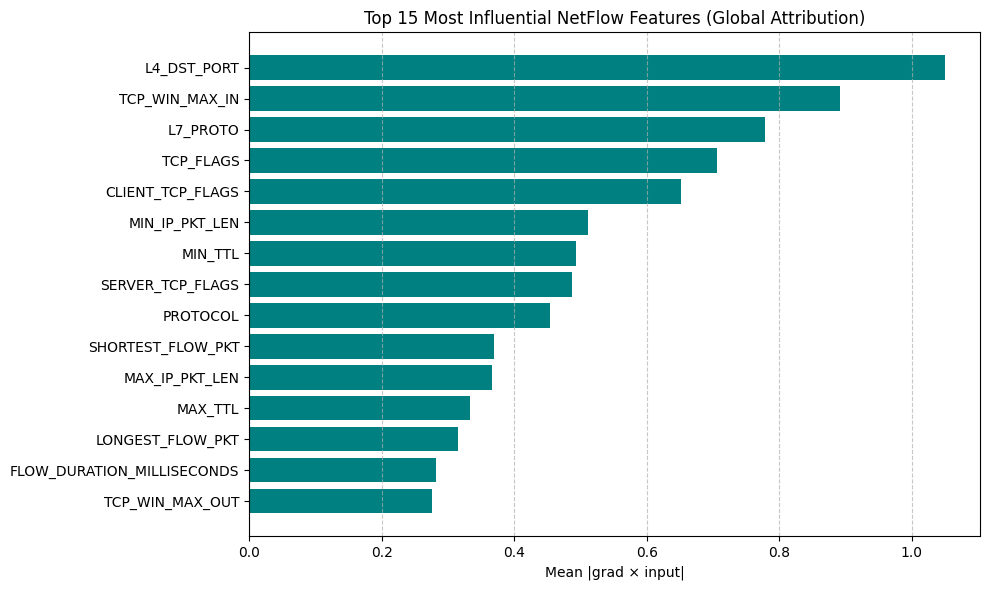

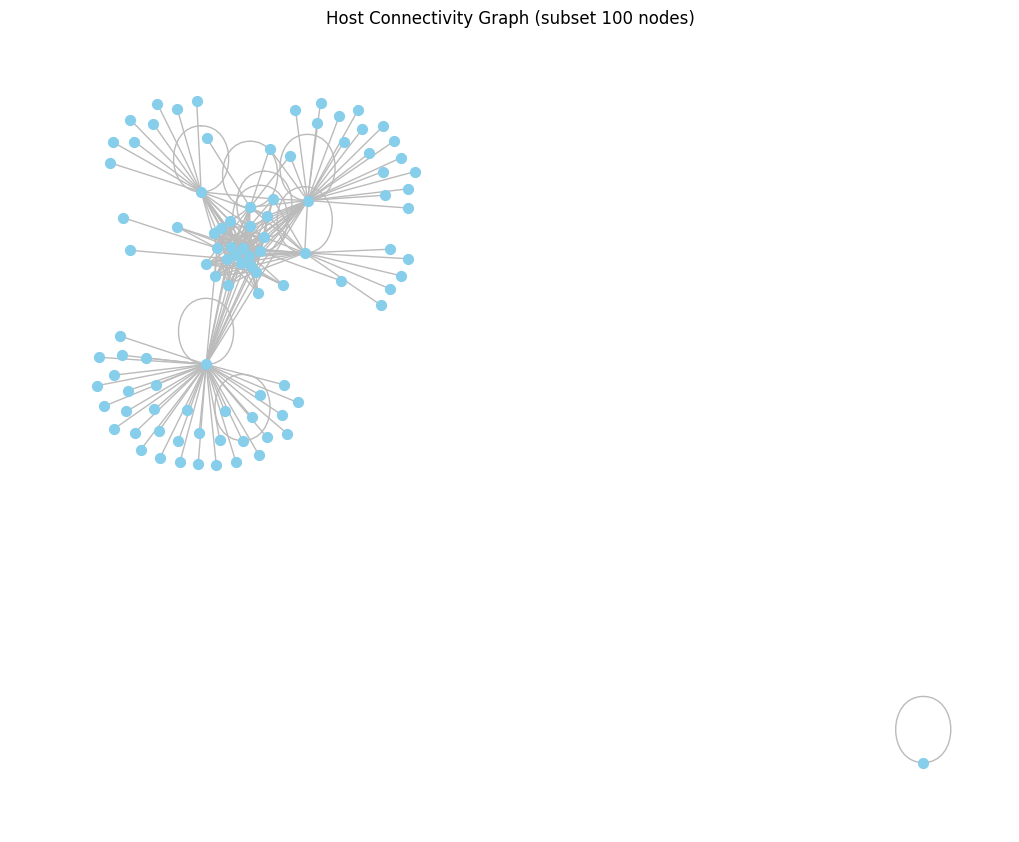

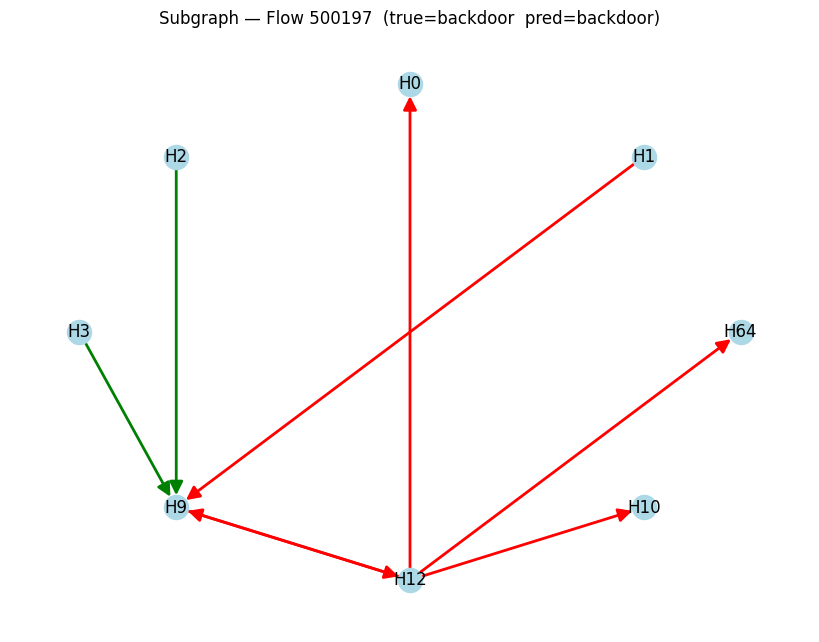

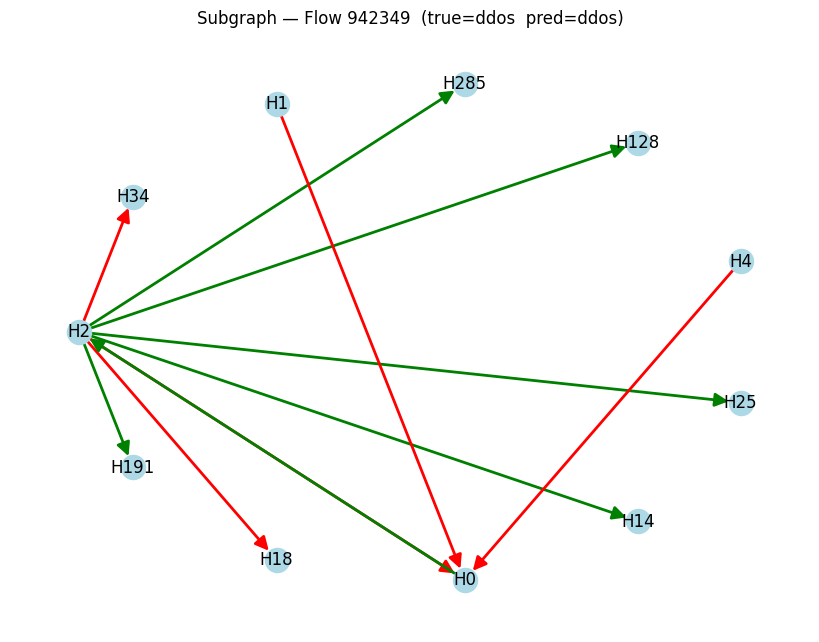

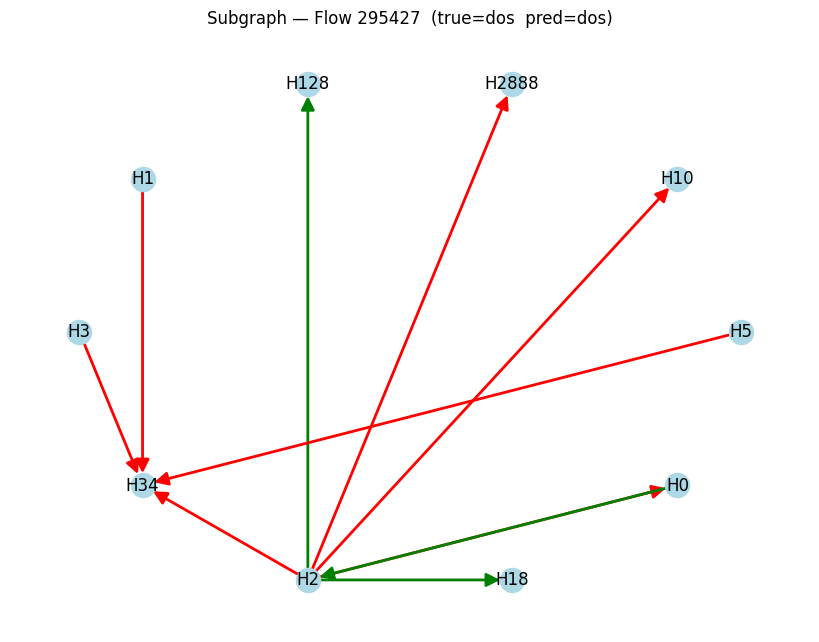

In [27]:
# =============================================================================
# 21. VISUALIZATIONS
# =============================================================================

print("Computing global attribution (n=50) ...")
samp_fi  = np.random.RandomState(SEED).choice(test_attack_idx, 50, replace=False)
avg_attr = np.mean(
    [feature_attribution_local(int(fi), model, graph, scaler) for fi in samp_fi], axis=0)
top_idx  = np.argsort(avg_attr)[-15:]

plt.figure(figsize=(10, 6))
plt.barh([EDGE_FEATURE_COLS[i] for i in top_idx], avg_attr[top_idx], color='teal')
plt.title("Top 15 Most Influential NetFlow Features (Global Attribution)")
plt.xlabel("Mean |grad × input|")
plt.grid(axis='x', ls='--', alpha=0.7)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_global_attribution.pdf', dpi=150, bbox_inches='tight')
plt.show()


def plot_global_graph(g: Data, num_nodes: int = 100, save_path=None):
    G = nx.Graph()
    m = (g.edge_index[0] < num_nodes) & (g.edge_index[1] < num_nodes)
    G.add_edges_from(g.edge_index[:, m].t().cpu().numpy())
    plt.figure(figsize=(10, 8))
    nx.draw(G, nx.spring_layout(G, seed=SEED), node_size=50,
            node_color='skyblue', edge_color='#bbbbbb', with_labels=False)
    plt.title(f"Host Connectivity Graph (subset {num_nodes} nodes)")
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_global_graph(graph, save_path=OUTPUT_DIR / 'fig_host_graph.pdf')


def visualize_subgraph(flow_idx: int, df_: pd.DataFrame, save_path=None):
    nbr = extract_flow_subgraph(flow_idx, df_)
    G   = nx.DiGraph()
    for _, r in nbr.iterrows():
        G.add_edge(f"H{int(r['src_idx'])}", f"H{int(r['dst_idx'])}",
                   color='red' if r['Label'] == 1 else 'green')
    plt.figure(figsize=(8, 6))
    cols = [G[u][v]['color'] for u, v in G.edges()]
    nx.draw(G, nx.shell_layout(G), with_labels=True,
            node_color='lightblue', edge_color=cols, width=2, arrowsize=20)
    plt.title(f"Subgraph — Flow {flow_idx}  "
              f"(true={le.classes_[graph.edge_y[flow_idx].item()]}  "
              f"pred={le.classes_[preds[flow_idx]]})")
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

for fi in [int(df.iloc[test_attack_idx][df.iloc[test_attack_idx]['Attack'] == nm]
               .sample(1, random_state=SEED).index[0])
           for nm in le.classes_ if nm != 'Benign'
           and len(df.iloc[test_attack_idx][df.iloc[test_attack_idx]['Attack'] == nm]) > 0
           ][:3]:
    visualize_subgraph(fi, df,
        save_path=OUTPUT_DIR / f'fig_subgraph_{le.classes_[graph.edge_y[fi].item()]}.pdf')

In [28]:
# =============================================================================
# 22. FINAL SUMMARY
# =============================================================================

print_timing_summary()

print("\n" + "="*60)
print("RAG-IDS v4 — FINAL TEST SET METRICS")
print("="*60)
print(classification_report(true[mask], preds[mask],
                             target_names=le.classes_, digits=4))
print(f"  Accuracy     : {accuracy_score(true[mask], preds[mask]):.4f}")
print(f"  Macro F1     : {f1_score(true[mask], preds[mask], average='macro',    zero_division=0):.4f}")
print(f"  Weighted F1  : {f1_score(true[mask], preds[mask], average='weighted', zero_division=0):.4f}")
print("="*60)
print(f"\nAll outputs → {OUTPUT_DIR.resolve()}")


TIMING SUMMARY
  Dataset Loading                               00:00:09.16
  Graph Construction                            00:00:12.40
  Inference                                     00:00:08.11
  Faithfulness Evaluation                       00:01:50.38
  Large-Scale Structured LLM Analysis           00:07:52.98
  TOTAL                                         00:11:31.57

RAG-IDS v4 — FINAL TEST SET METRICS
              precision    recall  f1-score   support

      Benign     0.9902    0.9891    0.9896    140000
    backdoor     0.9996    0.9983    0.9989      2353
        ddos     0.9786    0.9802    0.9794     28000
         dos     0.9380    0.9931    0.9647     14000
   injection     0.9160    0.8634    0.8889     14000
        mitm     0.7822    0.4385    0.5619      1081
    password     0.9536    0.9417    0.9476     16800
  ransomware     0.9876    0.9979    0.9927       480
    scanning     0.9775    0.9671    0.9723     42000
         xss     0.9425    0.9834    0.9625   

## Paper Table 17 — attribution faithfulness (NF-ToN-IoT-v2 row)

Top-5 deletion drop (mean, median), AOPC, and the fraction of flows with a drop below 0.05, over
n = 100 test attack flows. Reuses `drops_top5` / `aopc_vals` from the faithfulness cell above when available.

In [29]:
# =============================================================================
# Paper Table 17 -- Faithfulness of Gradient x Input attributions (NF-ToN-IoT-v2 row)
# =============================================================================

if 'drops_top5' not in globals() or 'aopc_vals' not in globals():
    print("drops_top5/aopc_vals not found in memory -- recomputing (n=100 test attack flows) ...")
    test_attack_idx = (graph.test_edge_mask & (graph.edge_y != benign_class)
                       ).nonzero(as_tuple=True)[0].cpu().numpy()
    sample_fi  = np.random.RandomState(SEED).choice(test_attack_idx, 100, replace=False)
    drops_top5 = []
    aopc_vals  = []
    for fi in sample_fi:
        fi   = int(fi)
        attr = feature_attribution_local(fi, model, graph, scaler)
        d    = deletion_test_raw(fi, model, graph, scaler, top_n=5, precomputed_attr=attr)
        drops_top5.append(d['score_drop'])
        aopc, _ = aopc_curve(fi, model, graph, scaler, max_k=8, precomputed_attr=attr)
        aopc_vals.append(aopc)
    drops_top5 = np.array(drops_top5)
    aopc_vals  = np.array(aopc_vals)
else:
    print("Reusing drops_top5 / aopc_vals already computed by the Faithfulness Evaluation cell above.")

frac_drop_lt_005 = (drops_top5 < 0.05).mean()

print("\n" + "=" * 60)
print("TABLE 16 -- NF-ToN-IoT-v2")
print("=" * 60)
print(f"  Top-5 deletion drop (mean)   : {drops_top5.mean():.4f}")
print(f"  Top-5 deletion drop (median) : {np.median(drops_top5):.4f}")
print(f"  AOPC (mean)                  : {aopc_vals.mean():.4f}")
print(f"  Flows with drop < 0.05       : {frac_drop_lt_005:.2%}  (n={len(drops_top5)})")

Reusing drops_top5 / aopc_vals already computed by the Faithfulness Evaluation cell above.

TABLE 16 -- NF-ToN-IoT-v2
  Top-5 deletion drop (mean)   : 0.3898
  Top-5 deletion drop (median) : 0.3430
  AOPC (mean)                  : 0.2953
  Flows with drop < 0.05       : 25.00%  (n=100)


## Paper Table 10 — architectural ablation

Macro-F1 on the test split (seed 42, identical inductive splits) for: the full DOSSIER detector,
DOSSIER without gated reconstruction, DOSSIER without jumping-knowledge fusion, and a re-implemented
E-GraphSAGE (two layers, mean aggregation, no reconstruction branch in the classifier input).

In [30]:
def run_ablation_variant(variant_name: str, g, model_class=None,
                          inductive_override: bool = None,
                          node_feat_override: bool = False) -> dict:
    """Train one ablation variant with train_one_seed and evaluate on test."""
    global INDUCTIVE
    orig_inductive = INDUCTIVE

    if inductive_override is not None:
        INDUCTIVE = inductive_override

    _g  = g
    nfd = node_feat_dim
    if node_feat_override:
        nd  = np.stack([np.log1p(in_deg), np.log1p(out_deg),
                        np.log1p(tot_deg), ratio], axis=1).astype(np.float32)
        nd  = (nd - nd.mean(0)) / (nd.std(0) + 1e-9)
        x4  = torch.tensor(nd, dtype=torch.float32)
        _g  = Data(
            x=x4, edge_index=g.edge_index,
            edge_attr=g.edge_attr, edge_attr_raw=g.edge_attr_raw,
            edge_y=g.edge_y, edge_y_binary=g.edge_y_binary,
            train_edge_mask=g.train_edge_mask,
            val_edge_mask=g.val_edge_mask,
            test_edge_mask=g.test_edge_mask,
        )
        nfd = x4.size(1)

    print(f"\n{'-'*60}\n  >>  {variant_name}\n{'-'*60}")

    try:
        m, _ = train_one_seed(
            SEED, _g,
            EPOCHS=200, PATIENCE=25, BATCH=16384,
            verbose=False,
            model_class=model_class,
            node_in=nfd,
            label=variant_name,
        )
        pv, tv, *_ = run_inference(m, _g)
    finally:
        INDUCTIVE = orig_inductive

    msk = _g.test_edge_mask.cpu().numpy()
    result = {
        'variant':     variant_name,
        'acc':         accuracy_score(tv[msk], pv[msk]),
        'macro_f1':    f1_score(tv[msk], pv[msk], average='macro',    zero_division=0),
        'weighted_f1': f1_score(tv[msk], pv[msk], average='weighted', zero_division=0),
    }
    print(f"  DONE  {variant_name}  |  acc={result['acc']:.4f}  "
          f"macro-F1={result['macro_f1']:.4f}  weighted-F1={result['weighted_f1']:.4f}")
    return result

print("run_ablation_variant() ready.")

run_ablation_variant() ready.


In [31]:
# =============================================================================
# Paper Table 10 -- additional model variants
# ("w/o gated reconstruction" reuses EGraphSAGEv4_NoRecon defined above)
# =============================================================================

class EGraphSAGEv4_NoJK(EGraphSAGEv4):
    """'DOSSIER w/o jumping-knowledge fusion': classifier sees only the final
    (3rd) message-passing layer instead of the concatenation of all three;
    gating, reconstruction and interaction terms are unchanged."""
    def encode(self, x, mp_ei, mp_enc):
        h1 = self.drop(self.conv1(x,  mp_ei, mp_enc))
        h2 = self.drop(self.conv2(h1, mp_ei, mp_enc))
        h3 =           self.conv3(h2, mp_ei, mp_enc)
        return h3  # no self.jk(...) fusion


class EGraphSAGEBaseline(nn.Module):
    """'E-GraphSAGE (re-implemented)' -- Lo et al. (2022): 2-layer edge-aware
    GraphSAGE, mean aggregation, no jumping-knowledge, no reconstruction
    branch feeding the classifier (only [h_u, h_v, edge] is used, no
    interaction terms).

    Keeps the interface train_one_seed expects (rec_mean/rec_std buffers,
    4-tuple forward). Its small reconstruction head is trained by the shared
    L_rec term, but its output is never passed to the classifier.
    """
    def __init__(self, node_in: int, edge_in: int,
                 hidden: int = 192, edge_hidden: int = 96,
                 n_classes: int = 10):
        super().__init__()
        self.register_buffer("rec_mean", torch.tensor(0.0))
        self.register_buffer("rec_std",  torch.tensor(1.0))

        self.edge_enc = nn.Sequential(
            nn.Linear(edge_in, edge_hidden), nn.ReLU(), nn.LayerNorm(edge_hidden))
        self.conv1 = EdgeSAGEConv(node_in, edge_hidden, hidden)
        self.conv2 = EdgeSAGEConv(hidden,  edge_hidden, hidden)

        edge_feat_dim = 2 * hidden + edge_hidden  # [h_u, h_v, edge_attr] only
        self.edge_clf = nn.Sequential(
            nn.Linear(edge_feat_dim, hidden), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(hidden, n_classes))

        self.edge_recon = nn.Sequential(
            nn.Linear(edge_feat_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, edge_in))
        self.retrieval_proj = nn.Sequential(
            nn.Linear(edge_feat_dim, hidden), nn.ReLU(), nn.Linear(hidden, 128))

    def forward(self, x, mp_ei, mp_ea, target_ei=None, target_ea=None):
        if target_ei is None: target_ei = mp_ei
        if target_ea is None: target_ea = mp_ea
        mp_enc = self.edge_enc(mp_ea)
        h1 = self.conv1(x,  mp_ei, mp_enc)
        h  = self.conv2(h1, mp_ei, mp_enc)                # 2 layers, no JK
        t_enc = self.edge_enc(target_ea)
        u, v = target_ei
        h_u, h_v = h[u], h[v]
        edge_feat = torch.cat([h_u, h_v, t_enc], dim=-1)   # no interaction terms
        recon  = self.edge_recon(edge_feat)                # trained, unused downstream
        logits = self.edge_clf(edge_feat)                  # sees no recon signal
        r_emb  = F.normalize(self.retrieval_proj(edge_feat), p=2, dim=-1)
        return logits, recon, h, r_emb

print("Table 9 model classes ready: EGraphSAGEv4_NoJK, EGraphSAGEBaseline")

Table 9 model classes ready: EGraphSAGEv4_NoJK, EGraphSAGEBaseline



[START] Ablation Study -- Table 9
  DOSSIER (full model)              |  acc=0.9738  macro-F1=0.9259

------------------------------------------------------------
  >>  DOSSIER w/o gated reconstruction
------------------------------------------------------------
  DONE  DOSSIER w/o gated reconstruction  |  acc=0.9730  macro-F1=0.9252  weighted-F1=0.9725

------------------------------------------------------------
  >>  DOSSIER w/o jumping-knowledge
------------------------------------------------------------
  DONE  DOSSIER w/o jumping-knowledge  |  acc=0.9747  macro-F1=0.9273  weighted-F1=0.9743

------------------------------------------------------------
  >>  E-GraphSAGE (re-implemented)
------------------------------------------------------------
  DONE  E-GraphSAGE (re-implemented)  |  acc=0.9738  macro-F1=0.9263  weighted-F1=0.9734

  TABLE 9 -- THIS DATASET
                         variant      acc  macro_f1  weighted_f1
            DOSSIER (full model) 0.973754  0.925876    

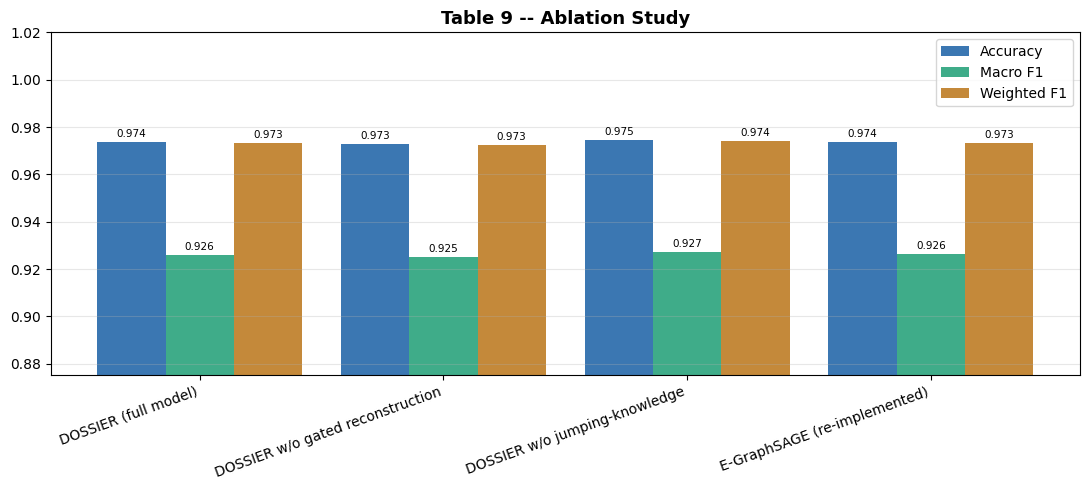

In [32]:
# =============================================================================
# Paper Table 10 -- the four comparisons (seed 42, identical inductive splits).
# The full model reuses the predictions of the seed-42 model above; the other
# three variants are trained here.
# =============================================================================

t = start_stage("Ablation Study -- Table 9")

ablation_results = []

msk = graph.test_edge_mask.cpu().numpy()
r_full = {
    'variant':     'DOSSIER (full model)',
    'acc':         accuracy_score(true[msk], preds[msk]),
    'macro_f1':    f1_score(true[msk], preds[msk], average='macro',    zero_division=0),
    'weighted_f1': f1_score(true[msk], preds[msk], average='weighted', zero_division=0),
}
print(f"  DOSSIER (full model)              |  acc={r_full['acc']:.4f}  macro-F1={r_full['macro_f1']:.4f}")
ablation_results.append(r_full)

ablation_results.append(run_ablation_variant(
    'DOSSIER w/o gated reconstruction', graph, model_class=EGraphSAGEv4_NoRecon))

ablation_results.append(run_ablation_variant(
    'DOSSIER w/o jumping-knowledge', graph, model_class=EGraphSAGEv4_NoJK))

ablation_results.append(run_ablation_variant(
    'E-GraphSAGE (re-implemented)', graph, model_class=EGraphSAGEBaseline))

abl_df = pd.DataFrame(ablation_results)
print(f"\n{'='*60}\n  TABLE 9 -- THIS DATASET\n{'='*60}")
print(abl_df.to_string(index=False))
abl_df.to_csv(OUTPUT_DIR / 'ablation_results_table9.csv', index=False)
end_stage("Ablation Study -- Table 9", t)


def plot_table9(abl_df_, save_path=None):
    variants = abl_df_['variant'].tolist()
    x, w     = np.arange(len(variants)), 0.28
    fig, ax  = plt.subplots(figsize=(11, 5))
    for offset, col, label, color in [
        (-w, 'acc',         'Accuracy',    '#185FA5'),
        ( 0, 'macro_f1',    'Macro F1',    '#1D9E75'),
        ( w, 'weighted_f1', 'Weighted F1', '#BA7517'),
    ]:
        bars = ax.bar(x + offset, abl_df_[col], w, label=label, color=color, alpha=0.85)
        for bar in bars:
            h = bar.get_height()
            ax.annotate(f'{h:.3f}',
                        xy=(bar.get_x() + w / 2, h),
                        xytext=(0, 2), textcoords='offset points',
                        ha='center', va='bottom', fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels(variants, rotation=20, ha='right')
    ax.set_ylim(max(0, abl_df_[['acc','macro_f1','weighted_f1']].min().min() - 0.05), 1.02)
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    ax.set_title('Table 9 -- Ablation Study', fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_table9(abl_df, save_path=OUTPUT_DIR / 'fig_table9_ablation.pdf')